# p05_aqr: テーマETFローテーション戦略のPPO拡張（Notebook完結）

- 参照戦略（S2-L / S2-R / EQW）を再現しつつ、PPO（factor/etf行動）を追加
- データリーク防止: 特徴量は決定時点tまで、適用はt+1
- 固定分割評価: applied return period 기준 `2021-01-01` 以降をテスト

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import yfinance as yf
from pathlib import Path
from IPython.display import display

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
import torch

pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
DATA_DIR = 'data/'
if not Path(DATA_DIR).exists():
    DATA_DIR = '../data/'
FACTO_NAME = 'etf.csv'
MACRO3_NAME = 'macro.csv'

real = pd.read_csv(DATA_DIR + FACTO_NAME, index_col=0, parse_dates=True)
macro = pd.read_csv(DATA_DIR + MACRO3_NAME, index_col=0, parse_dates=True)
TICKERS = real.columns
MACRO3 = ['CNY=X', '^IRX', '^VIX']
MACRO3

['CNY=X', '^IRX', '^VIX']

In [3]:
MACRO3

['CNY=X', '^IRX', '^VIX']

In [4]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(42)

def _convert_months_to_periods(month_value, scale):
    return max(1, int(round(float(month_value) * scale)))

def resolve_runtime_params(config):
    rebalance = str(config.get('rebalance', 'M')).upper()
    if rebalance == 'M':
        rule = 'ME'
        periods_per_year = 12
        scale = 1.0
        frequency_label = 'Monthly (EOM)'
    elif rebalance == 'W-FRI':
        rule = 'W-FRI'
        periods_per_year = 52
        scale = 52.0 / 12.0
        frequency_label = 'Weekly (W-FRI EOW)'
    else:
        raise ValueError("rebalance must be 'M' or 'W-FRI'.")

    pca_window = _convert_months_to_periods(config['pca_window_months'], scale)
    reg_window = _convert_months_to_periods(config['regression_window_months'], scale)
    min_obs = _convert_months_to_periods(config['min_obs_per_window'], scale)
    skip_periods = _convert_months_to_periods(config['factor_mom_skip_months'], scale)

    lookbacks_months = [int(x) for x in config['factor_mom_lookbacks']]
    lookbacks_periods = [_convert_months_to_periods(x, scale) for x in lookbacks_months]

    # 変換後lookbackが重複する場合はweightを合算
    raw_cw = {int(k): float(v) for k, v in config['combine_weights'].items()}
    combined = {}
    for lb_month, lb_period in zip(lookbacks_months, lookbacks_periods):
        w = raw_cw.get(lb_month, 0.0)
        combined[lb_period] = combined.get(lb_period, 0.0) + w

    if sum(combined.values()) == 0:
        unique_lb = sorted(set(lookbacks_periods))
        combined = {lb: 1.0 / len(unique_lb) for lb in unique_lb}
    else:
        s = sum(combined.values())
        combined = {k: v / s for k, v in combined.items()}

    lookbacks_periods = sorted(set(lookbacks_periods))

    return {
        'rebalance': rebalance,
        'rule': rule,
        'periods_per_year': periods_per_year,
        'scale': scale,
        'frequency_label': frequency_label,
        'pca_window': pca_window,
        'reg_window': reg_window,
        'min_obs': min_obs,
        'skip_periods': skip_periods,
        'lookbacks_periods': lookbacks_periods,
        'combine_weights_periods': combined,
        'lookback_month_to_period': dict(zip(lookbacks_months, [_convert_months_to_periods(x, scale) for x in lookbacks_months])),
    }


CONFIG = {
    # Data scope
    'start_date': None,
    'end_date': None,
    'tickers': TICKERS,
    'rebalance': 'W-FRI',  # 'M' or 'W-FRI'
    'cost_bps': 10,
    'benchmark': 'EQW',

    # Data source
    'local_csv_path': '../data/theme_etf.csv',

    # Factor construction (monthly meaning; converted to runtime periods)
    'factor_method': 'pca',
    'pca_window_months': 60,
    'n_components': 8,
    'standardize': True,
    'min_obs_per_window': 24,

    # Factor momentum (monthly meaning; converted to runtime periods)
    'factor_mom_lookbacks': [1, 12],
    'factor_mom_skip_months': 1,
    'combine_weights': {1: 0.5, 12: 0.5},
    'factor_weighting': 'top_m',
    'top_m_factors': 3,
    'exclude_pcs': [1],

    # ETF mapping (monthly meaning; converted to runtime periods)
    'etf_mapping_modes': ['loadings', 'regression'],
    'regression_window_months': 60,

    # Portfolio constraints
    'long_only': True,
    'weight_cap': None,

    # PPO settings
    'rl': {
        'split_date': '2019-01-01',
        'action_modes': ['factor'], #['factor', 'etf'],
        'reward_objectives': ['differential_sharpe'], #['differential_sharpe', 'mean_variance'],
        'reward_primary': 'compare',
        'reward_base': 'net',
        'reward_scale': 1.0,  # legacy scale (not used when stabilizer is enabled)
        'train_rebalance': 'W-FRI',
        'total_timesteps_factor': 1000,
        'total_timesteps_etf': 1000,
        'seed': 42,
        'history_len': 4,
        'include_action_history': True,
        'agent_state_fields': ['gross', 'net', 'turnover', 'drawdown'],
        'risk_estimator': {
            'type': 'ewma',
            'half_life_periods': 26,
            'eps': 1e-8,
        },
        'mean_variance': {
            'lambda': 5.0,
        },
        'differential_sharpe': {
            'eps': 1e-8,
        },
        'reward_stabilizer': {
            'standardize': True,
            'tanh_clip': True,
            'tanh_scale': 2.0,
            'eps': 1e-8,
        },
        'learning_curve': {
            'enable': True,
            'smooth_span': 20,
            'metrics': [
                'rollout/ep_rew_mean',
                'train/value_loss',
                'train/policy_gradient_loss',
                'train/entropy_loss',
            ],
            'min_points_warn': 10,
        },
        'macro': {
            'enable_macro': True,
            'source': 'local_csv',
            'zscore_window_months': 6,
            'series_list': [
                {
                    'name': 'vix',
                    'path': 'data/macro.csv',
                    'date_col': 'Date',
                    'value_col': '^VIX',
                    'feature_types': ['level', 'ret_1', 'zscore']
                },
                {
                    'name': 'cny',
                    'path': 'data/macro.csv',
                    'date_col': 'Date',
                    'value_col': 'CNY=X',
                    'feature_types': ['level', 'ret_1', 'zscore']
                },{
                    'name': 'irx',
                    'path': 'data/macro.csv',
                    'date_col': 'Date',
                    'value_col': '^IRX',
                    'feature_types': ['level', 'ret_1', 'zscore']
                },
            ]
        },
        'synthetic': {
            'enable_pretrain': True,
            'xlsx_path': 'data/synthetic.xlsx',
            'sheet_names': None,
            'macro_cols': ['CNY=X', '^IRX', '^VIX'],
            'pretrain_pca_mode': 'global_all_scenarios',
            'timestep_budget_mode': 'fixed_total_distribute',
            'one_episode_per_sheet': True,
            'pretrain_logs_enable': True,
        },
        'ppo_params': {
            'learning_rate': 3e-4,
            'n_steps': 256,
            'batch_size': 64,
            'n_epochs': 10,
            'gamma': 0.99,
            'gae_lambda': 0.95,
            'clip_range': 0.2,
            'ent_coef': 0.0,
            'vf_coef': 0.5,
            'max_grad_norm': 0.5,
        },
        'policy_kwargs': {
            'net_arch': [64, 64],
        },
    },
}

RUNTIME = resolve_runtime_params(CONFIG)

print('Config loaded')
print(f"rebalance={CONFIG['rebalance']} | runtime_rule={RUNTIME['rule']} | freq={RUNTIME['frequency_label']}")
print(
    f"tickers={len(CONFIG['tickers'])}, "
    f"pca_window={RUNTIME['pca_window']}, reg_window={RUNTIME['reg_window']}, "
    f"periods_per_year={RUNTIME['periods_per_year']}, cost_bps={CONFIG['cost_bps']}"
)
print('lookbacks(periods)=', RUNTIME['lookbacks_periods'])
print('combine_weights(periods)=', RUNTIME['combine_weights_periods'])

print('rl split_date=', CONFIG['rl']['split_date'], '| action_modes=', CONFIG['rl']['action_modes'])
print('rl reward_objectives=', CONFIG['rl']['reward_objectives'])
print('rl learning_curve=', CONFIG['rl']['learning_curve'])
print('rl history_len=', CONFIG['rl']['history_len'], '| state_fields=', CONFIG['rl']['agent_state_fields'])
print('rl macro=', CONFIG['rl']['macro'])

print('rl synthetic=', CONFIG['rl'].get('synthetic', {}))


Config loaded
rebalance=W-FRI | runtime_rule=W-FRI | freq=Weekly (W-FRI EOW)
tickers=9, pca_window=260, reg_window=260, periods_per_year=52, cost_bps=10
lookbacks(periods)= [4, 52]
combine_weights(periods)= {4: 0.5, 52: 0.5}
rl split_date= 2019-01-01 | action_modes= ['factor']
rl reward_objectives= ['differential_sharpe']
rl learning_curve= {'enable': True, 'smooth_span': 20, 'metrics': ['rollout/ep_rew_mean', 'train/value_loss', 'train/policy_gradient_loss', 'train/entropy_loss'], 'min_points_warn': 10}
rl history_len= 4 | state_fields= ['gross', 'net', 'turnover', 'drawdown']
rl macro= {'enable_macro': True, 'source': 'local_csv', 'zscore_window_months': 6, 'series_list': [{'name': 'vix', 'path': 'data/macro.csv', 'date_col': 'Date', 'value_col': '^VIX', 'feature_types': ['level', 'ret_1', 'zscore']}, {'name': 'cny', 'path': 'data/macro.csv', 'date_col': 'Date', 'value_col': 'CNY=X', 'feature_types': ['level', 'ret_1', 'zscore']}, {'name': 'irx', 'path': 'data/macro.csv', 'date_col':

In [5]:
raw = pd.read_csv(DATA_DIR + FACTO_NAME, index_col=0, parse_dates=True)
raw = raw.sort_index().reindex(columns=TICKERS)

median_abs = float(raw.abs().median().median())
looks_like_price_panel = bool(median_abs > 1.5)

if looks_like_price_panel:
    factor_rets = raw.pct_change()
    print('[INFO] etf.csv interpreted as price panel; converted to returns via pct_change().')
else:
    factor_rets = raw.copy()
    print('[INFO] etf.csv interpreted as return panel.')

factor_rets = factor_rets.replace([np.inf, -np.inf], np.nan)
px_d = (1 + factor_rets.fillna(0.0)).cumprod()

raw = pd.read_csv(DATA_DIR + MACRO3_NAME, index_col=0, parse_dates=True)
macro_data = raw.copy()
macro_data = macro_data.reindex(columns=MACRO3)
macro_data = macro_data.sort_index().dropna()
macro_data

[INFO] etf.csv interpreted as price panel; converted to returns via pct_change().


,CNY=X,^IRX,^VIX
Date,,,
2001-06-25,8.2768,3.3600,20.6700
2001-06-26,8.2768,3.4100,21.2000
2001-07-02,8.2770,3.5600,18.7600
2001-07-09,8.2767,3.5500,22.4800
2001-07-11,8.2769,3.4900,24.0100
...,...,...,...
2026-03-06,6.8970,3.5700,29.4900
2026-03-09,6.8965,3.5930,25.5000
2026-03-10,6.9110,3.5950,24.9300


In [6]:
## 3) Daily -> Periodic (ME or W-FRI)

def to_periodic(px_d, rule):
    px_p = px_d.resample(rule).last()
    ret_p = px_p.pct_change()
    return px_p, ret_p

px_p, ret_p = to_periodic(px_d, RUNTIME['rule'])

print(f"Rebalance mode: {RUNTIME['frequency_label']} (rule={RUNTIME['rule']})")
print('Timing: decide at period-end t and apply to next period return (t+1)')
print(f"Periodic range: {ret_p.index.min().date()} -> {ret_p.index.max().date()} (obs={len(ret_p)})")
print('Periodic return panel shape:', ret_p.shape)

ret_p.iloc[-5:, :8]

Rebalance mode: Weekly (W-FRI EOW) (rule=W-FRI)
Timing: decide at period-end t and apply to next period return (t+1)
Periodic range: 2000-01-07 -> 2026-03-13 (obs=1367)
Periodic return panel shape: (1367, 9)


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Date,,,,,,,,
2026-02-13,0.0349,0.0207,-0.0481,0.0057,-0.0111,0.0179,0.0727,-0.0003
2026-02-20,-0.0066,0.0098,0.0163,0.0176,0.0095,-0.0181,-0.0037,-0.0054
2026-02-27,0.0085,0.0190,-0.0202,-0.0005,-0.0150,0.0241,0.0302,0.0216
2026-03-06,-0.0665,0.0116,-0.0167,-0.0406,-0.0106,-0.0470,-0.0207,-0.0468
2026-03-13,-0.0004,0.0072,-0.0184,-0.0026,0.0229,-0.0139,-0.0122,0.0010


In [7]:
## 4) Utils (metrics / plots / turnover)

def normalize_long_only(w):
    w = w.clip(lower=0.0)
    total = w.sum()
    if total > 0:
        return w / total
    return w * 0.0


def normalize_ls(w):
    gross = w.abs().sum()
    if gross > 0:
        return w / gross
    return w * 0.0


def apply_weight_cap(w, cap=None):
    if cap is None:
        return w
    w = w.clip(upper=cap)
    if (w >= 0).all():
        return normalize_long_only(w)
    return normalize_ls(w)


def compute_turnover(w_t, w_prev):
    return 0.5 * np.abs(w_t - w_prev).sum()


def calc_drawdown(equity):
    peak = equity.cummax()
    return equity / peak - 1.0


def next_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])
    nxt = int(pos) + 1
    if nxt >= len(idx):
        return None
    return idx[nxt]


def prev_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.start
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][0])
    prv = int(pos) - 1
    if prv < 0:
        return None
    return idx[prv]


def calc_metrics(net_ret, turnover, periods_per_year):
    r = net_ret.dropna()
    if len(r) == 0:
        return pd.Series({'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan, 'MDD': np.nan, 'Turnover': np.nan, 'Hit': np.nan})

    years = len(r) / float(periods_per_year)
    cagr = (1.0 + r).prod() ** (1.0 / years) - 1.0 if years > 0 else np.nan
    std = r.std(ddof=0)
    vol = std * np.sqrt(periods_per_year)
    sharpe = (r.mean() / std * np.sqrt(periods_per_year)) if std > 0 else 0.0

    equity = (1.0 + r).cumprod()
    mdd = calc_drawdown(equity).min()
    to = turnover.reindex(r.index).mean()
    hit = (r > 0).mean()

    return pd.Series({'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MDD': mdd, 'Turnover': to, 'Hit': hit})


def run_backtest(weights_by_t, ret_p, cost_bps):
    if weights_by_t.empty:
        idx = pd.DatetimeIndex([], name='period')
        empty = pd.Series(index=idx, dtype=float)
        return empty.copy(), empty.copy(), empty.copy(), empty.copy(), empty.copy()

    weights_by_t = weights_by_t.sort_index().fillna(0.0)
    tickers = list(weights_by_t.columns)

    decision_periods = []
    applied_periods = []
    gross_vals = []
    net_vals = []
    turn_vals = []

    w_prev = pd.Series(0.0, index=tickers)

    for t, w_t in weights_by_t.iterrows():
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue

        r_next = ret_p.loc[apply_t].reindex(tickers).fillna(0.0)
        w_t = w_t.reindex(tickers).fillna(0.0)

        turnover = compute_turnover(w_t, w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (cost_bps / 10000.0)

        decision_periods.append(t)
        applied_periods.append(apply_t)
        gross_vals.append(gross)
        net_vals.append(net)
        turn_vals.append(turnover)

        w_prev = w_t

    idx = pd.DatetimeIndex(applied_periods, name='period')
    gross_s = pd.Series(gross_vals, index=idx, name='gross')
    net_s = pd.Series(net_vals, index=idx, name='net')
    turnover_s = pd.Series(turn_vals, index=idx, name='turnover')

    equity = (1.0 + net_s).cumprod().rename('equity')
    dd = calc_drawdown(equity).rename('drawdown')

    decision_idx = pd.DatetimeIndex(decision_periods, name='decision_period')
    for s in (gross_s, net_s, turnover_s, equity, dd):
        s.attrs['decision_periods'] = decision_idx

    return gross_s, net_s, turnover_s, equity, dd


def build_eqw(eligibility_by_t, ret_p, cost_bps):
    tickers = list(eligibility_by_t.columns)
    rows = {}
    for t, elig in eligibility_by_t.sort_index().iterrows():
        elig = elig.reindex(tickers).fillna(False)
        w = pd.Series(0.0, index=tickers)
        n = int(elig.sum())
        if n > 0:
            w.loc[elig.index[elig.values]] = 1.0 / n
        rows[t] = w

    weights_eqw = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=tickers).fillna(0.0)
    _, eqw_net, eqw_turnover, eqw_equity, eqw_dd = run_backtest(weights_eqw, ret_p, cost_bps)

    return eqw_net, eqw_turnover, eqw_equity, eqw_dd


def resolve_excluded_factor_labels(exclude_pcs, factor_columns):
    labels = [c for c in factor_columns if isinstance(c, str) and c.startswith('F') and c[1:].isdigit()]
    valid_nums = {int(c[1:]) for c in labels}

    excluded = set()
    invalid = []
    for raw in (exclude_pcs or []):
        try:
            n = int(raw)
        except (TypeError, ValueError):
            invalid.append(raw)
            continue

        if n in valid_nums:
            excluded.add(f'F{n}')
        else:
            invalid.append(raw)

    if invalid:
        print(f"[WARN] invalid exclude_pcs ignored: {invalid}")

    return excluded

def apply_factor_exclusion(factor_mom, excluded_labels):
    factor_mom_ex = factor_mom.copy()
    cols = [c for c in excluded_labels if c in factor_mom_ex.columns]
    if cols:
        factor_mom_ex.loc[:, cols] = np.nan
    return factor_mom_ex

def plot_equity_dd(equity_map, dd_map, title_prefix='Strategy Comparison'):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for name, s in equity_map.items():
        axes[0].plot(s.index, s.values, label=name, linewidth=2)
    axes[0].set_title(f'{title_prefix} - Equity Curve')
    axes[0].set_ylabel('Equity (start=1)')
    axes[0].legend()

    for name, s in dd_map.items():
        axes[1].plot(s.index, s.values, label=name, linewidth=1.8)
    axes[1].set_title(f'{title_prefix} - Drawdown Curve')
    axes[1].set_ylabel('Drawdown')
    axes[1].set_xlabel(f"Period ({RUNTIME['rule']})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [8]:
## 5) Rolling PCA factor construction

def build_rolling_pca(ret_p, runtime):
    window = runtime['pca_window']
    n_components = CONFIG['n_components']
    standardize = CONFIG.get('standardize', True)
    min_obs = runtime['min_obs']

    factor_cols = [f'F{i+1}' for i in range(n_components)]
    factor_ret = pd.DataFrame(index=ret_p.index, columns=factor_cols, dtype=float)

    loadings_by_t = {}
    elig_count = pd.Series(index=ret_p.index, dtype=float)
    eligibility_mask_by_t = {}

    prev_loadings = None

    for i, t in enumerate(ret_p.index):
        if i < window - 1:
            continue

        win = ret_p.iloc[i - window + 1 : i + 1]
        obs = win.notna().sum()
        elig = obs >= min_obs
        elig = elig.reindex(ret_p.columns).fillna(False)
        # 決定期tで観測不能なETFは投資対象外
        elig = elig & ret_p.loc[t].notna().reindex(ret_p.columns).fillna(False)

        eligibility_mask_by_t[t] = elig
        elig_count.loc[t] = int(elig.sum())

        if int(elig.sum()) < 2:
            continue

        x = win.loc[:, elig.index[elig.values]].copy()

        # 窓内のみで欠損補完（未来情報不使用）
        x = x.apply(lambda col: col.fillna(col.mean()), axis=0)
        x = x.fillna(0.0)

        if standardize:
            mu = x.mean(axis=0)
            sd = x.std(axis=0, ddof=0).replace(0.0, 1.0)
            x_std = (x - mu) / sd
        else:
            x_std = x

        k = min(n_components, x_std.shape[1], x_std.shape[0])
        if k < 1:
            continue

        pca = PCA(n_components=k, random_state=42)
        scores = pca.fit_transform(x_std.values)
        loadings = pd.DataFrame(pca.components_.T, index=x_std.columns, columns=[f'F{i+1}' for i in range(k)])

        # PCA符号の時系列整合
        if prev_loadings is not None:
            common_assets = loadings.index.intersection(prev_loadings.index)
            common_factors = loadings.columns.intersection(prev_loadings.columns)
            for fc in common_factors:
                if len(common_assets) == 0:
                    continue
                sign_anchor = float((loadings.loc[common_assets, fc] * prev_loadings.loc[common_assets, fc]).sum())
                if sign_anchor < 0:
                    loadings[fc] *= -1.0
                    col_idx = list(loadings.columns).index(fc)
                    scores[:, col_idx] *= -1.0

        prev_loadings = loadings.copy()

        f_t = pd.Series(scores[-1, :], index=loadings.columns)
        factor_ret.loc[t, f_t.index] = f_t.values
        loadings_by_t[t] = loadings

    elig_count = elig_count.fillna(0).astype(int).rename('eligible_count_pca')
    elig_count.attrs['eligibility_mask_by_t'] = eligibility_mask_by_t

    return factor_ret, loadings_by_t, elig_count


factor_ret, loadings_by_t, elig_pca_count = build_rolling_pca(ret_p, RUNTIME)

print('PCA factor return sample (tail):')
display(factor_ret.tail())

PCA factor return sample (tail):


,F1,F2,F3,F4,F5,F6,F7,F8
Date,,,,,,,,
2026-02-13,0.6087,-0.9532,-2.5681,-1.7843,-0.6237,-0.2247,1.9804,-0.3811
2026-02-20,-0.0320,1.1630,0.0019,-0.2199,-0.3846,0.5992,-0.3973,0.1831
2026-02-27,0.5281,-1.8791,-0.7360,0.0353,-0.1385,-0.7307,0.3629,-0.4227
2026-03-06,-4.2345,1.8897,-0.2653,-1.4068,-0.6331,0.1154,-1.1328,0.0730
2026-03-13,-0.6995,0.7474,0.3021,0.0588,-0.7493,-0.4775,0.4751,0.1550


In [9]:
## 6) Factor momentum signals (multi-L) + factor allocation

def compute_factor_mom(factor_ret, lookbacks_periods, skip_periods, combine_weights_periods):
    # combine_weights を正規化（未正規化入力でも可）
    lookbacks = sorted(set(int(x) for x in lookbacks_periods))

    raw_w = {int(k): float(v) for k, v in combine_weights_periods.items() if int(k) in lookbacks}
    s = sum(raw_w.values())
    if s == 0:
        norm_w = {int(L): 1.0 / len(lookbacks) for L in lookbacks}
    else:
        norm_w = {int(L): raw_w.get(int(L), 0.0) / s for L in lookbacks}

    mom_parts = {}
    for L in lookbacks:
        L = int(L)
        # 短期lookbackは通常モメンタム、長期lookbackは skip を反映
        start_lag = 1
        if skip_periods > 0 and L > (skip_periods + 1):
            start_lag = skip_periods + 1

        lagged = [factor_ret.shift(j) for j in range(start_lag, L + 1)]
        mom_L = sum(lagged) if lagged else factor_ret * np.nan
        mom_parts[L] = mom_L

    mom_df = sum(norm_w[L] * mom_parts[L] for L in lookbacks)
    return mom_df, mom_parts, norm_w


def allocate_factor_weights(mom_t, method='top_m', top_m=3, long_only=True):
    x = mom_t.dropna().copy()
    if len(x) == 0:
        return pd.Series(index=mom_t.index, data=0.0)

    if method == 'top_m':
        winners = x.nlargest(min(top_m, len(x)))
        w = pd.Series(0.0, index=x.index)
        if long_only:
            winners = winners[winners > 0]
            if len(winners) > 0:
                w.loc[winners.index] = 1.0 / len(winners)
        else:
            w.loc[winners.index] = 1.0 / len(winners)

    elif method == 'rank':
        r = x.rank(method='average', ascending=True)
        w = r - r.min()
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w - w.mean())

    elif method == 'sign':
        w = np.sign(x)
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w)

    else:
        raise ValueError(f'Unknown factor_weighting method: {method}')

    # full factor indexへ戻す
    out = pd.Series(0.0, index=mom_t.index)
    out.loc[w.index] = w.values

    if long_only:
        out = normalize_long_only(out)
    else:
        out = normalize_ls(out)

    return out


factor_mom_raw, mom_parts, norm_cw = compute_factor_mom(
    factor_ret=factor_ret,
    lookbacks_periods=RUNTIME['lookbacks_periods'],
    skip_periods=RUNTIME['skip_periods'],
    combine_weights_periods=RUNTIME['combine_weights_periods'],
)

excluded_factor_labels = resolve_excluded_factor_labels(CONFIG.get('exclude_pcs', []), factor_mom_raw.columns)
factor_mom = apply_factor_exclusion(factor_mom_raw, excluded_factor_labels)

print('Runtime lookbacks(periods):', RUNTIME['lookbacks_periods'])
print('Runtime skip(periods):', RUNTIME['skip_periods'])
print('Normalized combine_weights(periods):', norm_cw)
print('Check sum(combine_weights_normalized)=', sum(norm_cw.values()))
print('exclude_pcs(raw)=', CONFIG.get('exclude_pcs', []))
print('excluded_factor_labels(resolved)=', sorted(excluded_factor_labels))

if len(excluded_factor_labels) == len(factor_mom.columns):
    print('[INFO] All factor sleeves are excluded: allocation will be cash (zero weights).')



Runtime lookbacks(periods): [4, 52]
Runtime skip(periods): 4
Normalized combine_weights(periods): {4: 0.5, 52: 0.5}
Check sum(combine_weights_normalized)= 1.0
exclude_pcs(raw)= [1]
excluded_factor_labels(resolved)= ['F1']


In [10]:
## 7) S2-L: mapping(loadings) + backtest + plots

def map_loadings_to_etf(loadings_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index

    fac = loadings_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = loadings_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w


all_tickers = ret_p.columns.tolist()
eligibility_mask_by_t = elig_pca_count.attrs['eligibility_mask_by_t']


Common comparison window: 2004-12-31 -> 2026-03-13 (1107 periods)


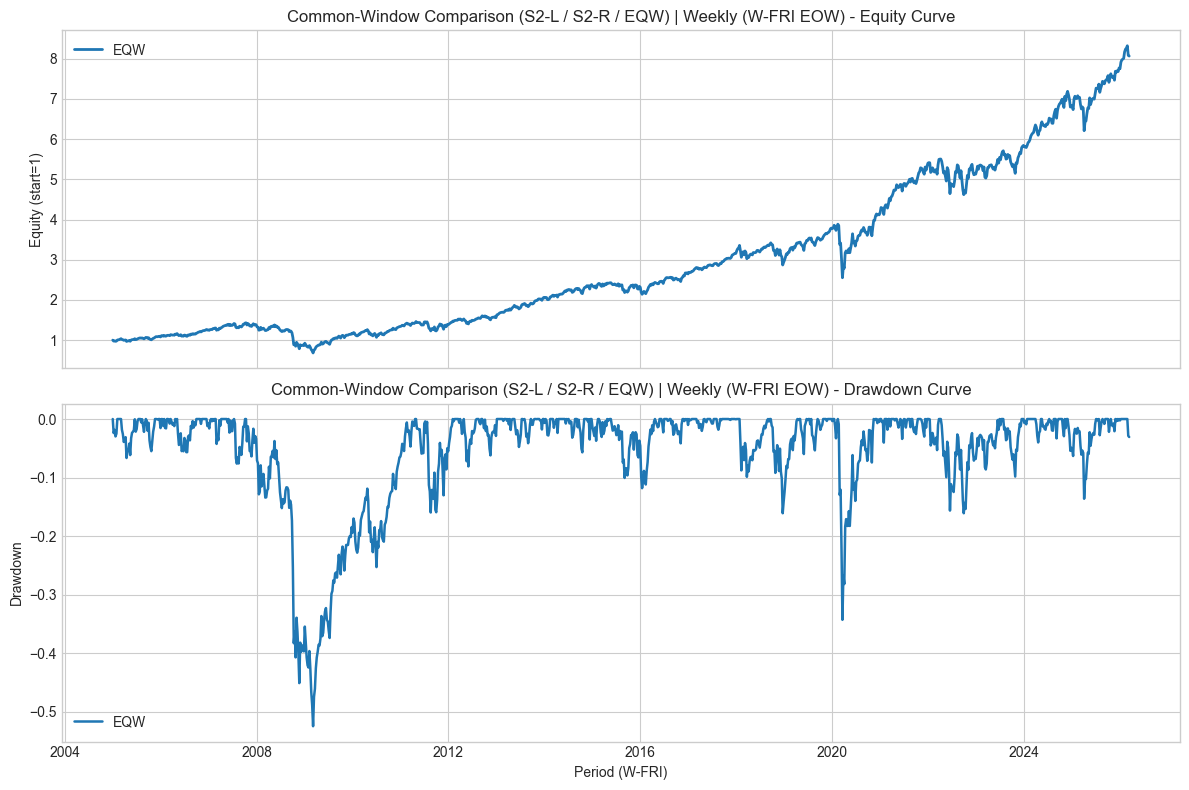

In [11]:
## 9) Compare (S2-L vs S2-R vs EQW) equity & drawdown

# EQW eligibility: PCAの時点tで投資候補になったETFを採用
eligibility_eqw = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)
elig_eqw_count = eligibility_eqw.sum(axis=1).rename('eligible_count_eqw')

eqw_net, eqw_turnover, eqw_equity, eqw_dd = build_eqw(eligibility_eqw, ret_p, CONFIG['cost_bps'])

common_idx = eqw_net.index
if len(common_idx) == 0:
    raise ValueError('No common comparison period among S2-L, S2-R, EQW.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common comparison window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

eqw_net_c = eqw_net.reindex(common_idx)

eqw_turn_c = eqw_turnover.reindex(common_idx)

eqw_equity_c = (1 + eqw_net_c).cumprod()

eqw_dd_c = calc_drawdown(eqw_equity_c)

plot_equity_dd(
    equity_map={'EQW': eqw_equity_c},
    dd_map={'EQW': eqw_dd_c},
    title_prefix=f"Common-Window Comparison (S2-L / S2-R / EQW) | {RUNTIME['frequency_label']}"
)

In [12]:
## 11) Diagnostics (leak check / eligibility counts + risk gates)

# leak check: factor signal uses <= decision period data, and return application is t+1 period

def make_leak_check_table(net_series, ret_index, name='strategy'):
    decision_periods = net_series.attrs.get('decision_periods', pd.DatetimeIndex([], name='decision_period'))
    applied_periods = net_series.index

    n = min(len(decision_periods), len(applied_periods))
    decision_periods = decision_periods[:n]
    applied_periods = applied_periods[:n]

    prev_periods = [prev_period_index(ret_index, t) for t in decision_periods]

    leak_tbl = pd.DataFrame({
        'strategy': name,
        'decision_period': decision_periods,
        'max_signal_data_period': prev_periods,
        'applied_return_period': applied_periods,
    })

    return leak_tbl

## 12) PPO特徴量（tまでの情報のみ）

In [13]:
all_tickers = ret_p.columns.tolist()
factor_cols = factor_mom.columns.tolist()
excluded_factor_labels = set(f'F{i}' for i in CONFIG.get('exclude_pcs', []))
rl_factor_cols = [c for c in factor_mom.columns.tolist() if c not in excluded_factor_labels]

eligibility_df = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)


def load_macro_local_csv(path, date_col='Date', value_col='Close', series_name='macro'):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{series_name} local CSV not found: {path}')

    df = pd.read_csv(path)
    required = {date_col, value_col}
    if not required.issubset(set(df.columns)):
        raise ValueError(
            f'{series_name} CSV must contain columns {sorted(required)}. '
            f'got={df.columns.tolist()}'
        )

    out = df[[date_col, value_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[value_col] = pd.to_numeric(out[value_col], errors='coerce')
    out = out.dropna(subset=[date_col, value_col])
    out = out.sort_values(date_col).drop_duplicates(subset=[date_col], keep='last')
    out = out.set_index(date_col)

    s = out[value_col].rename(series_name)
    if not s.index.is_monotonic_increasing:
        s = s.sort_index()
    return s


def build_single_macro_features(series_daily, rule, prefix, zscore_window_periods, feature_types=('level', 'ret_1', 'zscore')):
    series_p = series_daily.resample(rule).last().rename(f'{prefix}_level')
    blocks = []

    if 'level' in feature_types:
        blocks.append(series_p.rename(f'{prefix}_level'))

    if 'ret_1' in feature_types:
        blocks.append(series_p.pct_change().rename(f'{prefix}_ret_1'))

    if 'diff_1' in feature_types:
        blocks.append(series_p.diff().rename(f'{prefix}_diff_1'))

    if 'zscore' in feature_types:
        w = max(2, int(zscore_window_periods))
        mu = series_p.shift(1).rolling(window=w, min_periods=w).mean()
        sd = series_p.shift(1).rolling(window=w, min_periods=w).std(ddof=0).replace(0.0, np.nan)
        z = ((series_p - mu) / sd).rename(f'{prefix}_zscore')
        blocks.append(z)

    out = pd.concat(blocks, axis=1)
    out = out.ffill().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out


def build_macro_feature_panel(macro_cfg, rule, runtime, ret_index):
    if str(macro_cfg.get('source', '')).lower() != 'local_csv':
        raise ValueError("Only local_csv source is supported for macro series in this notebook.")

    series_list = macro_cfg.get('series_list', [])
    if len(series_list) == 0:
        return pd.DataFrame(index=ret_index), {}

    z_window = _convert_months_to_periods(macro_cfg.get('zscore_window_months', 6), runtime['scale'])

    blocks = []
    raw_series = {}

    for spec in series_list:
        name = str(spec['name'])
        print(name)
        s_daily = load_macro_local_csv(
            path=spec['path'],
            date_col=spec.get('date_col', 'Date'),
            value_col=spec.get('value_col', 'Close'),
            series_name=name,
        )
        raw_series[name] = s_daily

        feat_i = build_single_macro_features(
            series_daily=s_daily,
            rule=rule,
            prefix=name,
            zscore_window_periods=z_window,
            feature_types=tuple(spec.get('feature_types', ['level', 'ret_1', 'zscore'])),
        )
        blocks.append(feat_i)

        print(
            f'{name} loaded: rows={len(s_daily)} | '
            f'range={s_daily.index.min().date()} -> {s_daily.index.max().date()} | '
            f'features={feat_i.columns.tolist()}'
        )

    macro_features = pd.concat(blocks, axis=1).sort_index()
    macro_features = macro_features.reindex(ret_index).ffill().fillna(0.0)

    print(f'Macro periodic features: rows={len(macro_features)} | z_window(periods)={z_window}')
    return macro_features, raw_series


def build_rl_features(ret_p, factor_mom, eligibility_by_t, macro_features=None, lags=(0, 1, 4, 12), cs_mom_lookback=12):
    blocks = []

    # 価格リターンのラグ特徴（t, t-1, t-4, t-12 など）
    for lag in lags:
        lag_df = ret_p.shift(int(lag)).copy()
        lag_df.columns = [f'ret_lag{int(lag)}__{c}' for c in lag_df.columns]
        blocks.append(lag_df)

    # 横断面モメンタム順位（時点tで利用可能な銘柄内）
    cs_mom = ret_p.fillna(0.0).rolling(int(cs_mom_lookback), min_periods=2).sum()
    cs_rank = pd.DataFrame(index=ret_p.index, columns=ret_p.columns, dtype=float)

    for t in ret_p.index:
        if t in eligibility_by_t.index:
            elig_t = eligibility_by_t.loc[t].reindex(ret_p.columns).fillna(False)
        else:
            elig_t = pd.Series(False, index=ret_p.columns)

        vals = cs_mom.loc[t].where(elig_t).dropna()
        if len(vals) > 0:
            cs_rank.loc[t, vals.index] = vals.rank(method='average', pct=True)

    cs_rank = cs_rank.fillna(0.0)
    cs_rank.columns = [f'cs_rank__{c}' for c in cs_rank.columns]
    blocks.append(cs_rank)

    fac = factor_mom.reindex(ret_p.index).fillna(0.0).copy()
    fac.columns = [f'factor_mom__{c}' for c in fac.columns]
    blocks.append(fac)

    elig_feat = eligibility_by_t.reindex(ret_p.index).reindex(columns=ret_p.columns).fillna(False).astype(float)
    elig_feat.columns = [f'elig__{c}' for c in elig_feat.columns]
    blocks.append(elig_feat)

    if macro_features is not None and len(macro_features.columns) > 0:
        macro_aligned = macro_features.reindex(ret_p.index).ffill().fillna(0.0)
        blocks.append(macro_aligned)

    feat = pd.concat(blocks, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    valid_idx = [t for t in feat.index if next_period_index(ret_p.index, t) is not None]
    feat = feat.loc[valid_idx].sort_index()

    return feat




def synthetic_daily_ret_to_periodic(ret_d, rule):
    ret_d = ret_d.sort_index().replace([np.inf, -np.inf], np.nan)
    gross = (1.0 + ret_d).resample(rule).prod(min_count=1)
    ret_p = gross - 1.0
    return ret_p


def load_synthetic_scenarios(xlsx_path, ticker_cols, macro_cols, sheet_names=None):
    xlsx_path = Path(xlsx_path)
    if not xlsx_path.exists():
        raise FileNotFoundError(f'synthetic xlsx not found: {xlsx_path}')

    xl = pd.ExcelFile(xlsx_path)
    if sheet_names is None:
        use_sheets = list(xl.sheet_names)
    else:
        sheet_names = list(sheet_names)
        use_sheets = [s for s in sheet_names if s in xl.sheet_names]

    if len(use_sheets) == 0:
        raise ValueError(f'No valid sheet found in {xlsx_path}. requested={sheet_names}, available={xl.sheet_names}')

    required_cols = ['Date'] + list(ticker_cols) + list(macro_cols)
    scenarios = []

    for sheet in use_sheets:
        df = xl.parse(sheet)
        miss = [c for c in required_cols if c not in df.columns]
        if miss:
            raise ValueError(f'synthetic sheet={sheet} missing columns: {miss}')

        out = df[required_cols].copy()
        out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
        out = out.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date'], keep='last').set_index('Date')
        out = out.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)

        scenarios.append({
            'name': str(sheet),
            'daily': out,
            'ret_d': out.reindex(columns=ticker_cols),
            'macro_d': out.reindex(columns=macro_cols),
        })

    return scenarios


def fit_global_pca_for_synthetic(scenarios, runtime, config):
    synthetic_cfg = config['rl'].get('synthetic', {})
    pca_mode = str(synthetic_cfg.get('pretrain_pca_mode', 'global_all_scenarios')).lower()
    if pca_mode != 'global_all_scenarios':
        raise ValueError(f'Unsupported synthetic pretrain_pca_mode: {pca_mode}')

    ticker_cols = list(config['tickers'])
    periodic_blocks = []

    for sc in scenarios:
        ret_p_i = synthetic_daily_ret_to_periodic(sc['ret_d'].reindex(columns=ticker_cols), runtime['rule'])
        ret_p_i = ret_p_i.reindex(columns=ticker_cols)
        periodic_blocks.append(ret_p_i)

    all_ret_p = pd.concat(periodic_blocks, axis=0)
    all_ret_p = all_ret_p.replace([np.inf, -np.inf], np.nan)

    x = all_ret_p.copy()
    mu = x.mean(axis=0).reindex(ticker_cols).fillna(0.0)
    x = x.fillna(mu).fillna(0.0)

    standardize = bool(config.get('standardize', True))
    if standardize:
        sd = x.std(axis=0, ddof=0).replace(0.0, 1.0).reindex(ticker_cols).fillna(1.0)
        x_std = (x - mu) / sd
    else:
        sd = pd.Series(1.0, index=ticker_cols)
        x_std = x

    k = min(int(config['n_components']), x_std.shape[1], x_std.shape[0])
    if k < 1:
        raise ValueError('Synthetic global PCA failed: insufficient observations/components')

    pca = PCA(n_components=k, random_state=42)
    pca.fit(x_std.values)

    factor_cols_local = [f'F{i+1}' for i in range(k)]
    loadings = pd.DataFrame(pca.components_.T, index=ticker_cols, columns=factor_cols_local)

    return {
        'pca': pca,
        'mu': mu,
        'sd': sd,
        'standardize': standardize,
        'loadings': loadings,
        'factor_cols': factor_cols_local,
        'ticker_cols': ticker_cols,
    }


def transform_scenario_with_global_pca(scenario_ret_p, pca_pack):
    ticker_cols = list(pca_pack['ticker_cols'])
    x = scenario_ret_p.reindex(columns=ticker_cols).copy()
    x = x.replace([np.inf, -np.inf], np.nan)

    mu = pca_pack['mu'].reindex(ticker_cols).fillna(0.0)
    sd = pca_pack['sd'].reindex(ticker_cols).replace(0.0, 1.0).fillna(1.0)

    x_filled = x.fillna(mu).fillna(0.0)
    if bool(pca_pack['standardize']):
        x_input = (x_filled - mu) / sd
    else:
        x_input = x_filled

    scores = pca_pack['pca'].transform(x_input.values)

    factor_cols_local = list(pca_pack['factor_cols'])
    factor_ret = pd.DataFrame(scores, index=x.index, columns=factor_cols_local)

    loadings = pca_pack['loadings'].copy()
    loadings_by_t = {t: loadings for t in factor_ret.index}

    eligibility_df = x.notna().reindex(columns=ticker_cols).fillna(False).astype(bool)

    return factor_ret, loadings_by_t, eligibility_df


def build_macro_feature_panel_from_sheet(sheet_daily, macro_cols, macro_cfg, rule, runtime, ret_index):
    if not bool(macro_cfg.get('enable_macro', False)):
        return pd.DataFrame(index=ret_index), {}

    z_window = _convert_months_to_periods(macro_cfg.get('zscore_window_months', 6), runtime['scale'])
    series_specs = {str(s.get('value_col', '')): dict(s) for s in macro_cfg.get('series_list', [])}

    blocks = []
    raw_series = {}

    for col in macro_cols:
        if col not in sheet_daily.columns:
            continue

        s_daily = pd.to_numeric(sheet_daily[col], errors='coerce').dropna().sort_index()
        if len(s_daily) == 0:
            continue

        spec = series_specs.get(col, {})
        series_name = str(spec.get('name', str(col).replace('^', '').replace('=', '').replace('/', '_').lower()))
        feature_types = tuple(spec.get('feature_types', ['level', 'ret_1', 'zscore']))

        s_daily = s_daily.rename(series_name)
        raw_series[series_name] = s_daily

        feat_i = build_single_macro_features(
            series_daily=s_daily,
            rule=rule,
            prefix=series_name,
            zscore_window_periods=z_window,
            feature_types=feature_types,
        )
        blocks.append(feat_i)

    if len(blocks) == 0:
        return pd.DataFrame(index=ret_index), raw_series

    macro_features = pd.concat(blocks, axis=1).sort_index()
    macro_features = macro_features.reindex(ret_index).ffill().fillna(0.0)

    return macro_features, raw_series


def build_synthetic_bundle(scenario, pca_pack, runtime, config):
    ticker_cols = list(config['tickers'])
    macro_cfg_local = config['rl'].get('macro', {})
    synthetic_cfg = config['rl'].get('synthetic', {})
    macro_cols_local = list(synthetic_cfg.get('macro_cols', ['CNY=X', '^IRX', '^VIX']))

    ret_p_syn = synthetic_daily_ret_to_periodic(
        scenario['ret_d'].reindex(columns=ticker_cols),
        runtime['rule'],
    ).reindex(columns=ticker_cols)

    factor_ret_syn, loadings_syn_by_t, eligibility_df_syn = transform_scenario_with_global_pca(
        scenario_ret_p=ret_p_syn,
        pca_pack=pca_pack,
    )

    factor_mom_raw_syn, _, _ = compute_factor_mom(
        factor_ret=factor_ret_syn,
        lookbacks_periods=runtime['lookbacks_periods'],
        skip_periods=runtime['skip_periods'],
        combine_weights_periods=runtime['combine_weights_periods'],
    )

    excluded_factor_labels_syn = resolve_excluded_factor_labels(config.get('exclude_pcs', []), factor_mom_raw_syn.columns)
    factor_mom_syn = apply_factor_exclusion(factor_mom_raw_syn, excluded_factor_labels_syn)

    macro_features_syn, macro_raw_series_syn = build_macro_feature_panel_from_sheet(
        sheet_daily=scenario['daily'],
        macro_cols=macro_cols_local,
        macro_cfg=macro_cfg_local,
        rule=runtime['rule'],
        runtime=runtime,
        ret_index=ret_p_syn.index,
    )

    rl_features_syn = build_rl_features(
        ret_p=ret_p_syn,
        factor_mom=factor_mom_syn,
        eligibility_by_t=eligibility_df_syn,
        macro_features=macro_features_syn,
        lags=(0, 1, 4, 12),
        cs_mom_lookback=12,
    )

    base_decisions_syn = sorted(set(rl_features_syn.index).intersection(set(eligibility_df_syn.index)))
    base_decisions_syn = [t for t in base_decisions_syn if bool(eligibility_df_syn.loc[t].sum() > 0)]

    factor_decisions_syn = [t for t in base_decisions_syn if t in loadings_syn_by_t]
    etf_decisions_syn = base_decisions_syn.copy()

    decisions_map_syn = {
        'factor': pd.DatetimeIndex(factor_decisions_syn),
        'etf': pd.DatetimeIndex(etf_decisions_syn),
    }

    return {
        'name': scenario['name'],
        'ret_p': ret_p_syn,
        'eligibility_df': eligibility_df_syn,
        'factor_ret': factor_ret_syn,
        'factor_mom': factor_mom_syn,
        'loadings_by_t': loadings_syn_by_t,
        'macro_features': macro_features_syn,
        'macro_raw_series': macro_raw_series_syn,
        'rl_features': rl_features_syn,
        'decisions_map': decisions_map_syn,
    }


def build_synthetic_pretrain_bundles(config, runtime):
    synthetic_cfg = config['rl'].get('synthetic', {})
    if not bool(synthetic_cfg.get('enable_pretrain', False)):
        return [], None

    scenarios = load_synthetic_scenarios(
        xlsx_path=synthetic_cfg.get('xlsx_path', 'data/synthetic.xlsx'),
        ticker_cols=list(config['tickers']),
        macro_cols=list(synthetic_cfg.get('macro_cols', ['CNY=X', '^IRX', '^VIX'])),
        sheet_names=synthetic_cfg.get('sheet_names', None),
    )

    pca_pack = fit_global_pca_for_synthetic(
        scenarios=scenarios,
        runtime=runtime,
        config=config,
    )

    bundles = [
        build_synthetic_bundle(scenario=sc, pca_pack=pca_pack, runtime=runtime, config=config)
        for sc in scenarios
    ]

    return bundles, pca_pack


macro_cfg = CONFIG['rl']['macro']
macro_features = pd.DataFrame(index=ret_p.index)
macro_raw_series = {}

if bool(macro_cfg.get('enable_macro', False)):
    macro_features, macro_raw_series = build_macro_feature_panel(
        macro_cfg=macro_cfg,
        rule=RUNTIME['rule'],
        runtime=RUNTIME,
        ret_index=ret_p.index,
    )
else:
    print("Macro feature is disabled in CONFIG['rl']['macro'].")

rl_features = build_rl_features(
    ret_p=ret_p,
    factor_mom=factor_mom,
    eligibility_by_t=eligibility_df,
    macro_features=macro_features,
    lags=(0, 1, 4, 12),
    cs_mom_lookback=12,
)

print('RL feature matrix shape:', rl_features.shape)
print('RL feature sample columns:', rl_features.columns[:8].tolist())
print('RL macro columns:', list(macro_features.columns))
display(rl_features.tail(3))

vix
vix loaded: rows=5968 | range=2001-06-25 -> 2026-03-12 | features=['vix_level', 'vix_ret_1', 'vix_zscore']
cny
cny loaded: rows=5968 | range=2001-06-25 -> 2026-03-12 | features=['cny_level', 'cny_ret_1', 'cny_zscore']
irx
irx loaded: rows=5968 | range=2001-06-25 -> 2026-03-12 | features=['irx_level', 'irx_ret_1', 'irx_zscore']
Macro periodic features: rows=1367 | z_window(periods)=26
RL feature matrix shape: (1366, 71)
RL feature sample columns: ['ret_lag0__XLB', 'ret_lag0__XLE', 'ret_lag0__XLF', 'ret_lag0__XLI', 'ret_lag0__XLK', 'ret_lag0__XLP', 'ret_lag0__XLU', 'ret_lag0__XLV']
RL macro columns: ['vix_level', 'vix_ret_1', 'vix_zscore', 'cny_level', 'cny_ret_1', 'cny_zscore', 'irx_level', 'irx_ret_1', 'irx_zscore']


,ret_lag0__XLB,ret_lag0__XLE,ret_lag0__XLF,ret_lag0__XLI,ret_lag0__XLK,ret_lag0__XLP,ret_lag0__XLU,ret_lag0__XLV,ret_lag0__XLY,ret_lag1__XLB,...,elig__XLY,vix_level,vix_ret_1,vix_zscore,cny_level,cny_ret_1,cny_zscore,irx_level,irx_ret_1,irx_zscore
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-20,-0.0066,0.0098,0.0163,0.0176,0.0095,-0.0181,-0.0037,-0.0054,0.0109,0.0349,...,1.0000,19.0900,-0.0733,0.8246,6.9081,0.0012,-2.1139,3.5950,0.0006,-0.7793
2026-02-27,0.0085,0.0190,-0.0202,-0.0005,-0.0150,0.0241,0.0302,0.0216,-0.0050,-0.0066,...,1.0000,19.8600,0.0403,1.0617,6.8409,-0.0097,-2.7731,3.5780,-0.0047,-0.8437
2026-03-06,-0.0665,0.0116,-0.0167,-0.0406,-0.0106,-0.0470,-0.0207,-0.0468,-0.0207,0.0085,...,1.0000,29.4900,0.4849,4.7111,6.8970,0.0082,-1.7245,3.5700,-0.0022,-0.8580


## 13) PPO環境・ポリシーI/F

In [14]:
def softmax(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    z = x - np.max(x)
    e = np.exp(z)
    s = e.sum()
    if s <= 0:
        return np.full_like(e, 1.0 / len(e), dtype=float)
    return e / s


def init_history_buffers(n_tickers, history_len, state_fields):
    history_len = int(history_len)
    n_tickers = int(n_tickers)
    n_state = int(len(state_fields))

    action_history = deque(maxlen=history_len)
    state_history = deque(maxlen=history_len)

    zero_action = np.zeros(n_tickers, dtype=np.float32)
    zero_state = np.zeros(n_state, dtype=np.float32)

    for _ in range(history_len):
        action_history.append(zero_action.copy())
        state_history.append(zero_state.copy())

    return {'action_history': action_history, 'state_history': state_history}


def action_to_weights(action, mode, context):
    tickers = context['tickers']
    long_only = bool(context.get('long_only', True))
    cap = context.get('weight_cap', None)
    elig_t = context['elig_t'].reindex(tickers).fillna(False)

    if mode == 'factor':
        factor_cols = context['factor_cols']
        logits = np.asarray(action, dtype=float).reshape(-1)
        if len(logits) != len(factor_cols):
            raise ValueError(f'factor action dimension mismatch: got={len(logits)}, expected={len(factor_cols)}')

        w_factor = pd.Series(softmax(logits), index=factor_cols)
        loadings_t = context.get('loadings_t', None)

        if loadings_t is None or len(loadings_t) == 0:
            w_etf = pd.Series(0.0, index=tickers)
        else:
            w_etf = map_loadings_to_etf(loadings_t, w_factor, elig_t, cap=cap)

    elif mode == 'etf':
        logits = np.asarray(action, dtype=float).reshape(-1)
        if len(logits) != len(tickers):
            raise ValueError(f'etf action dimension mismatch: got={len(logits)}, expected={len(tickers)}')

        raw = pd.Series(softmax(logits), index=tickers)
        raw.loc[~elig_t] = 0.0
        w_etf = normalize_long_only(raw) if long_only else normalize_ls(raw - raw.mean())
        w_etf = apply_weight_cap(w_etf, cap=cap)

    else:
        raise ValueError(f'Unknown action mode: {mode}')

    w_etf = w_etf.reindex(tickers).fillna(0.0)
    w_etf.loc[~elig_t] = 0.0

    if long_only:
        w_etf = normalize_long_only(w_etf)
    else:
        w_etf = normalize_ls(w_etf)

    return w_etf


class ThemeRotationPPOEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(
        self,
        features_df,
        ret_p,
        eligibility_by_t,
        action_mode,
        cost_bps,
        long_only,
        tickers,
        factor_cols,
        reward_objective,
        reward_cfg,
        loadings_by_t=None,
        weight_cap=None,
        decision_index=None,
        history_len=4,
        agent_state_fields=None,
        include_action_history=True,
    ):
        super().__init__()

        self.features_df = features_df.copy()
        self.ret_p = ret_p.copy()
        self.eligibility_by_t = eligibility_by_t.copy()
        self.action_mode = str(action_mode)
        self.cost_bps = float(cost_bps)
        self.long_only = bool(long_only)
        self.tickers = list(tickers)
        self.factor_cols = list(factor_cols)
        self.loadings_by_t = loadings_by_t or {}
        self.weight_cap = weight_cap

        self.reward_objective = str(reward_objective)
        self.reward_cfg = dict(reward_cfg or {})

        self.history_len = int(history_len)
        self.include_action_history = bool(include_action_history)
        self.agent_state_fields = list(agent_state_fields or ['gross', 'net', 'turnover', 'drawdown'])

        if decision_index is None:
            raw_decisions = list(self.features_df.index)
        else:
            raw_decisions = list(pd.DatetimeIndex(decision_index))

        decision_periods = []
        applied_periods = []
        for t in raw_decisions:
            if t not in self.features_df.index:
                continue
            apply_t = next_period_index(self.ret_p.index, t)
            if apply_t is None:
                continue
            decision_periods.append(t)
            applied_periods.append(apply_t)

        if len(decision_periods) == 0:
            raise ValueError('No valid decision periods available for PPO environment.')

        self.decision_periods = pd.DatetimeIndex(decision_periods, name='decision_period')
        self.applied_periods = pd.DatetimeIndex(applied_periods, name='applied_period')

        self.obs_feature_dim = self.features_df.shape[1]
        self.action_history_dim = self.history_len * len(self.tickers) if self.include_action_history else 0
        self.state_history_dim = self.history_len * len(self.agent_state_fields)
        self.obs_dim = self.obs_feature_dim + self.action_history_dim + self.state_history_dim

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        if self.action_mode == 'factor':
            self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(len(self.factor_cols),), dtype=np.float32)
        elif self.action_mode == 'etf':
            self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(len(self.tickers),), dtype=np.float32)
        else:
            raise ValueError("action_mode must be 'factor' or 'etf'.")

        self._parse_reward_cfg()

        self._ptr = 0
        self._w_prev = pd.Series(0.0, index=self.tickers)
        self._equity = 1.0
        self._peak = 1.0
        self._drawdown = 0.0
        self._buffers = init_history_buffers(
            n_tickers=len(self.tickers),
            history_len=self.history_len,
            state_fields=self.agent_state_fields,
        )
        self._reset_reward_state()

    def _parse_reward_cfg(self):
        risk = self.reward_cfg.get('risk_estimator', {})
        if str(risk.get('type', 'ewma')).lower() != 'ewma':
            raise ValueError("Only EWMA risk estimator is supported.")

        self._half_life = float(risk.get('half_life_periods', 26))
        self._risk_eps = float(risk.get('eps', 1e-8))
        self._alpha = float(1.0 - np.exp(np.log(0.5) / max(1.0, self._half_life)))

        mv = self.reward_cfg.get('mean_variance', {})
        self._mv_lambda = float(mv.get('lambda', 5.0))

        ds = self.reward_cfg.get('differential_sharpe', {})
        self._ds_eps = float(ds.get('eps', 1e-8))

        st = self.reward_cfg.get('reward_stabilizer', {})
        self._st_standardize = bool(st.get('standardize', True))
        self._st_tanh = bool(st.get('tanh_clip', True))
        self._st_tanh_scale = float(st.get('tanh_scale', 2.0))
        self._st_eps = float(st.get('eps', 1e-8))

    def _reset_reward_state(self):
        self._net_mu = 0.0
        self._net_m2 = 0.0
        self._reward_mu = 0.0
        self._reward_m2 = 0.0

    def _eligibility_t(self, t):
        if t in self.eligibility_by_t.index:
            return self.eligibility_by_t.loc[t].reindex(self.tickers).fillna(False)
        return pd.Series(False, index=self.tickers)

    def _state_vector(self, gross, net, turnover, drawdown):
        state_map = {
            'gross': float(gross),
            'net': float(net),
            'turnover': float(turnover),
            'drawdown': float(drawdown),
        }
        return np.asarray([state_map[k] for k in self.agent_state_fields], dtype=np.float32)

    def _update_history(self, w_t, gross, net, turnover, drawdown):
        if self.include_action_history:
            self._buffers['action_history'].append(w_t.reindex(self.tickers).fillna(0.0).values.astype(np.float32))
        self._buffers['state_history'].append(self._state_vector(gross, net, turnover, drawdown))

    def _build_obs(self):
        t = self.decision_periods[self._ptr]
        feat = self.features_df.loc[t].values.astype(np.float32)

        obs_parts = [feat]

        if self.include_action_history:
            action_hist = np.concatenate(list(self._buffers['action_history']), axis=0).astype(np.float32)
            obs_parts.append(action_hist)

        state_hist = np.concatenate(list(self._buffers['state_history']), axis=0).astype(np.float32)
        obs_parts.append(state_hist)

        obs = np.concatenate(obs_parts, axis=0)
        return obs

    def _compute_reward(self, net):
        net = float(net)
        eps = max(self._risk_eps, self._ds_eps)

        mu_prev = float(self._net_mu)
        m2_prev = float(self._net_m2)
        var_prev = float(max(m2_prev - mu_prev * mu_prev, eps))
        sigma_prev = float(np.sqrt(var_prev))

        if self.reward_objective == 'differential_sharpe':
            s_prev = mu_prev / (sigma_prev + eps)
            z_t = (net - mu_prev) / (sigma_prev + eps)
            reward_raw = z_t - 0.5 * s_prev * (z_t * z_t - 1.0)
        elif self.reward_objective == 'mean_variance':
            reward_raw = net - self._mv_lambda * var_prev
        elif self.reward_objective == 'net_return':
            reward_raw = net
        else:
            raise ValueError(f'Unknown reward objective: {self.reward_objective}')

        # Update net EWMA moments after using t-1 stats in reward
        self._net_mu = (1.0 - self._alpha) * self._net_mu + self._alpha * net
        self._net_m2 = (1.0 - self._alpha) * self._net_m2 + self._alpha * (net * net)

        if self._st_standardize:
            r_mu_prev = float(self._reward_mu)
            r_m2_prev = float(self._reward_m2)
            r_var_prev = float(max(r_m2_prev - r_mu_prev * r_mu_prev, self._st_eps))
            r_std_prev = float(np.sqrt(r_var_prev))
            reward_norm = (reward_raw - r_mu_prev) / (r_std_prev + self._st_eps)
        else:
            reward_norm = reward_raw

        if self._st_tanh:
            reward_out = float(np.tanh(reward_norm / max(self._st_tanh_scale, self._st_eps)))
        else:
            reward_out = float(reward_norm)

        self._reward_mu = (1.0 - self._alpha) * self._reward_mu + self._alpha * reward_raw
        self._reward_m2 = (1.0 - self._alpha) * self._reward_m2 + self._alpha * (reward_raw * reward_raw)

        return {
            'reward': reward_out,
            'reward_raw': float(reward_raw),
            'reward_norm': float(reward_norm),
            'mu_prev': mu_prev,
            'var_prev': var_prev,
            'sigma_prev': sigma_prev,
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._ptr = 0
        self._w_prev = pd.Series(0.0, index=self.tickers)
        self._equity = 1.0
        self._peak = 1.0
        self._drawdown = 0.0
        self._buffers = init_history_buffers(
            n_tickers=len(self.tickers),
            history_len=self.history_len,
            state_fields=self.agent_state_fields,
        )
        self._reset_reward_state()

        obs = self._build_obs()
        info = {
            'decision_period': self.decision_periods[self._ptr],
            'applied_period': self.applied_periods[self._ptr],
        }
        return obs, info

    def step(self, action):
        t = self.decision_periods[self._ptr]
        apply_t = self.applied_periods[self._ptr]

        elig_t = self._eligibility_t(t)
        context = {
            'tickers': self.tickers,
            'factor_cols': self.factor_cols,
            'elig_t': elig_t,
            'long_only': self.long_only,
            'weight_cap': self.weight_cap,
            'loadings_t': self.loadings_by_t.get(t),
        }

        w_t = action_to_weights(action=action, mode=self.action_mode, context=context)

        r_next = self.ret_p.loc[apply_t].reindex(self.tickers).fillna(0.0)
        turnover = compute_turnover(w_t, self._w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (self.cost_bps / 10000.0)

        self._equity = float(self._equity * (1.0 + net))
        self._peak = float(max(self._peak, self._equity))
        self._drawdown = float(self._equity / self._peak - 1.0) if self._peak > 0 else 0.0

        self._update_history(w_t=w_t, gross=gross, net=net, turnover=turnover, drawdown=self._drawdown)

        reward_pack = self._compute_reward(net=net)
        reward = float(reward_pack['reward'])

        info = {
            'decision_period': t,
            'applied_period': apply_t,
            'gross': gross,
            'net': net,
            'turnover': float(turnover),
            'drawdown': float(self._drawdown),
            'equity': float(self._equity),
            'risk_mu_prev': float(reward_pack['mu_prev']),
            'risk_var_prev': float(reward_pack['var_prev']),
            'risk_sigma_prev': float(reward_pack['sigma_prev']),
            'reward_raw': float(reward_pack['reward_raw']),
            'reward_norm': float(reward_pack['reward_norm']),
            'reward_objective': self.reward_objective,
            'history_latest_period': prev_period_index(self.ret_p.index, t),
            'weights': w_t.copy(),
            'action': np.asarray(action, dtype=float).copy(),
        }

        self._w_prev = w_t.copy()
        self._ptr += 1

        terminated = self._ptr >= len(self.decision_periods)
        truncated = False

        if terminated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._build_obs()

        return obs, reward, terminated, truncated, info


## 14) PPO学習・推論ユーティリティ

In [15]:

def split_decision_periods_by_applied(decision_periods, ret_p, split_date):
    rows = []
    for t in pd.DatetimeIndex(decision_periods):
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue
        rows.append((t, apply_t))

    split_tbl = pd.DataFrame(rows, columns=['decision_period', 'applied_period']).drop_duplicates()
    split_tbl = split_tbl.sort_values('decision_period').reset_index(drop=True)

    split_date = pd.Timestamp(split_date)
    train_mask = split_tbl['applied_period'] < split_date
    test_mask = split_tbl['applied_period'] >= split_date

    train_decisions = pd.DatetimeIndex(split_tbl.loc[train_mask, 'decision_period'])
    test_decisions = pd.DatetimeIndex(split_tbl.loc[test_mask, 'decision_period'])

    return split_tbl, train_decisions, test_decisions


class TrainingLogCallback(BaseCallback):
    def __init__(self, metric_names, verbose=0):
        super().__init__(verbose)
        self.metric_names = list(metric_names)
        self.rows = []
        self.episode_rewards = deque(maxlen=100)

    def _on_step(self):
        infos = self.locals.get('infos', [])
        if infos is None:
            return True

        for info in infos:
            ep_info = info.get('episode') if isinstance(info, dict) else None
            if isinstance(ep_info, dict) and ('r' in ep_info):
                try:
                    self.episode_rewards.append(float(ep_info['r']))
                except (TypeError, ValueError):
                    pass
        return True

    def _on_rollout_end(self):
        logger_values = getattr(self.model.logger, 'name_to_value', {})
        row = {'num_timesteps': int(self.num_timesteps)}

        for metric in self.metric_names:
            value = logger_values.get(metric, np.nan)

            if metric == 'rollout/ep_rew_mean':
                try:
                    val_f = float(value)
                except (TypeError, ValueError):
                    val_f = np.nan

                if not np.isfinite(val_f) and len(self.episode_rewards) > 0:
                    val_f = float(np.mean(self.episode_rewards))
                row[metric] = val_f
                continue

            try:
                row[metric] = float(value)
            except (TypeError, ValueError):
                row[metric] = np.nan

        self.rows.append(row)

    def to_frame(self):
        df = pd.DataFrame(self.rows)
        if len(df) > 0:
            df = df.sort_values('num_timesteps').drop_duplicates('num_timesteps', keep='last').reset_index(drop=True)
        return df


def train_ppo(mode, train_env, config, init_parameters=None, ppo_params_override=None, total_timesteps_override=None):
    rl_cfg = config['rl']
    lc_cfg = rl_cfg.get('learning_curve', {})

    monitored_env = VecMonitor(train_env)
    policy_kwargs = {'net_arch': list(rl_cfg['policy_kwargs']['net_arch'])}

    ppo_params = dict(rl_cfg['ppo_params'])
    if ppo_params_override is not None:
        ppo_params.update(dict(ppo_params_override))

    model = PPO(
        policy='MlpPolicy',
        env=monitored_env,
        seed=int(rl_cfg['seed']),
        verbose=0,
        policy_kwargs=policy_kwargs,
        **ppo_params,
    )

    if init_parameters is not None:
        model.set_parameters(init_parameters, exact_match=False)

    metric_names = list(lc_cfg.get('metrics', [
        'rollout/ep_rew_mean',
        'train/value_loss',
        'train/policy_gradient_loss',
        'train/entropy_loss',
    ]))
    training_cb = TrainingLogCallback(metric_names=metric_names)

    if total_timesteps_override is None:
        total_timesteps = int(rl_cfg['total_timesteps_factor'] if mode == 'factor' else rl_cfg['total_timesteps_etf'])
    else:
        total_timesteps = int(total_timesteps_override)
    total_timesteps = max(1, total_timesteps)

    model.learn(total_timesteps=total_timesteps, progress_bar=False, callback=training_cb)

    train_log_df = training_cb.to_frame()
    return model, train_log_df


def evaluate_policy_to_weights(model, test_env):
    obs, _ = test_env.reset(seed=int(CONFIG['rl']['seed']))

    done = False
    rows = {}
    records = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)

        t = pd.Timestamp(info['decision_period'])
        rows[t] = info['weights']

        records.append({
            'decision_period': pd.Timestamp(info['decision_period']),
            'applied_period': pd.Timestamp(info['applied_period']),
            'history_latest_period': pd.Timestamp(info['history_latest_period']) if info.get('history_latest_period') is not None else pd.NaT,
            'gross': float(info['gross']),
            'net': float(info['net']),
            'turnover': float(info['turnover']),
            'drawdown': float(info['drawdown']),
            'equity': float(info['equity']),
            'risk_mu_prev': float(info['risk_mu_prev']),
            'risk_var_prev': float(info['risk_var_prev']),
            'risk_sigma_prev': float(info['risk_sigma_prev']),
            'reward_raw': float(info['reward_raw']),
            'reward_norm': float(info['reward_norm']),
            'reward_objective': str(info['reward_objective']),
            'reward': float(reward),
            'action_l2': float(np.linalg.norm(np.asarray(info['action'], dtype=float))),
            'action_raw': np.asarray(info['action'], dtype=float).tolist(),
        })

        done = bool(terminated or truncated)

    weights = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=test_env.tickers).fillna(0.0).sort_index()
    weights.index.name = 'decision_period'

    step_df = pd.DataFrame(records)
    if len(step_df) > 0:
        step_df = step_df.sort_values('decision_period').reset_index(drop=True)

    return weights, step_df


## 15) PPO学習（factor / etf）とバックテスト

In [16]:

def make_ppo_key(mode, reward_objective):
    return f'{mode}__{reward_objective}'


def make_ppo_label(mode, reward_objective):
    short_map = {
        'differential_sharpe': 'DSharpe',
        'mean_variance': 'MV',
    }
    return f"PPO-{mode}-{short_map.get(reward_objective, reward_objective)}"


def build_decisions_map(features_df, eligibility_df, loadings_by_t):
    base_decisions_local = sorted(set(features_df.index).intersection(set(eligibility_df.index)))
    base_decisions_local = [t for t in base_decisions_local if bool(eligibility_df.loc[t].sum() > 0)]

    factor_decisions_local = [t for t in base_decisions_local if t in loadings_by_t]
    etf_decisions_local = base_decisions_local.copy()

    return {
        'factor': pd.DatetimeIndex(factor_decisions_local),
        'etf': pd.DatetimeIndex(etf_decisions_local),
    }


def distribute_timesteps(total_timesteps, n_parts):
    total_timesteps = max(1, int(total_timesteps))
    n_parts = max(1, int(n_parts))
    base = total_timesteps // n_parts
    rem = total_timesteps % n_parts
    alloc = []
    for i in range(n_parts):
        alloc_i = base + (1 if i < rem else 0)
        alloc.append(max(1, int(alloc_i)))
    return alloc


split_date = pd.Timestamp(CONFIG['rl']['split_date'])

decisions_map = build_decisions_map(
    features_df=rl_features,
    eligibility_df=eligibility_df,
    loadings_by_t=loadings_by_t,
)

reward_cfg_common = {
    'reward_base': CONFIG['rl'].get('reward_base', 'net'),
    'risk_estimator': CONFIG['rl']['risk_estimator'],
    'mean_variance': CONFIG['rl']['mean_variance'],
    'differential_sharpe': CONFIG['rl']['differential_sharpe'],
    'reward_stabilizer': CONFIG['rl']['reward_stabilizer'],
}

synthetic_cfg = CONFIG['rl'].get('synthetic', {})
synthetic_bundles, synthetic_pca_pack = build_synthetic_pretrain_bundles(CONFIG, RUNTIME)

if bool(synthetic_cfg.get('enable_pretrain', False)):
    print(f"Synthetic pretrain enabled: scenarios={len(synthetic_bundles)} | pca_mode={synthetic_cfg.get('pretrain_pca_mode')}")
else:
    print('Synthetic pretrain disabled by CONFIG.')

ppo_results = {}
ppo_order = []

for mode in CONFIG['rl']['action_modes']:
    mode_decisions = decisions_map[mode]
    split_tbl, train_decisions, test_decisions = split_decision_periods_by_applied(
        decision_periods=mode_decisions,
        ret_p=ret_p,
        split_date=split_date,
    )

    assert len(set(train_decisions).intersection(set(test_decisions))) == 0, 'Split overlap detected.'
    assert len(train_decisions) > 0, f'Empty train_decisions for mode={mode}'
    assert len(test_decisions) > 0, f'Empty test_decisions for mode={mode}'

    for reward_objective in CONFIG['rl']['reward_objectives']:
        key = make_ppo_key(mode, reward_objective)
        label = make_ppo_label(mode, reward_objective)

        print('\n' + '=' * 72)
        print(f'PPO mode={mode} | reward_objective={reward_objective}')
        print(f'decision periods total={len(mode_decisions)} | train={len(train_decisions)} | test={len(test_decisions)}')

        pretrain_log_chunks = []
        pretrained_params = None

        if bool(synthetic_cfg.get('enable_pretrain', False)) and len(synthetic_bundles) > 0:
            total_pretrain_steps = int(CONFIG['rl']['total_timesteps_factor'] if mode == 'factor' else CONFIG['rl']['total_timesteps_etf'])
            step_alloc = distribute_timesteps(total_pretrain_steps, len(synthetic_bundles))

            for i, bundle in enumerate(synthetic_bundles):
                syn_decisions = bundle['decisions_map'][mode]
                if len(syn_decisions) == 0:
                    print(f"[pretrain] skip scenario={bundle['name']} (no decision periods for mode={mode})")
                    continue

                episode_len = int(len(syn_decisions))
                allocated_steps = int(step_alloc[i])
                effective_steps = int(min(max(1, allocated_steps), max(1, episode_len)))

                base_batch_size = int(CONFIG['rl']['ppo_params'].get('batch_size', 64))
                n_steps_override = max(2, episode_len)
                batch_override = max(2, min(base_batch_size, max(2, episode_len)))

                syn_env_kwargs = dict(
                    features_df=bundle['rl_features'],
                    ret_p=bundle['ret_p'],
                    eligibility_by_t=bundle['eligibility_df'],
                    action_mode=mode,
                    cost_bps=CONFIG['cost_bps'],
                    long_only=CONFIG['long_only'],
                    tickers=all_tickers,
                    factor_cols=rl_factor_cols,
                    reward_objective=reward_objective,
                    reward_cfg=reward_cfg_common,
                    loadings_by_t=bundle['loadings_by_t'],
                    weight_cap=CONFIG['weight_cap'],
                    decision_index=syn_decisions,
                    history_len=CONFIG['rl']['history_len'],
                    agent_state_fields=CONFIG['rl']['agent_state_fields'],
                    include_action_history=CONFIG['rl'].get('include_action_history', True),
                )

                syn_env = DummyVecEnv([lambda kwargs=syn_env_kwargs: ThemeRotationPPOEnv(**kwargs)])

                syn_model, syn_train_log = train_ppo(
                    mode=mode,
                    train_env=syn_env,
                    config=CONFIG,
                    init_parameters=pretrained_params,
                    ppo_params_override={
                        'n_steps': n_steps_override,
                        'batch_size': batch_override,
                    },
                    total_timesteps_override=effective_steps,
                )

                pretrained_params = syn_model.get_parameters()

                if bool(synthetic_cfg.get('pretrain_logs_enable', True)):
                    syn_train_log = syn_train_log.copy()
                    syn_train_log['scenario'] = bundle['name']
                    syn_train_log['mode'] = mode
                    syn_train_log['reward_objective'] = reward_objective
                    syn_train_log['episode_len'] = episode_len
                    syn_train_log['allocated_timesteps'] = allocated_steps
                    syn_train_log['effective_timesteps'] = effective_steps
                    pretrain_log_chunks.append(syn_train_log)

                print(
                    f"[pretrain] scenario={bundle['name']} | decisions={episode_len} | "
                    f"allocated={allocated_steps} | effective={effective_steps}"
                )

        pretrain_log_df = (
            pd.concat(pretrain_log_chunks, axis=0, ignore_index=True)
            if len(pretrain_log_chunks) > 0
            else pd.DataFrame()
        )

        train_env_kwargs = dict(
            features_df=rl_features,
            ret_p=ret_p,
            eligibility_by_t=eligibility_df,
            action_mode=mode,
            cost_bps=CONFIG['cost_bps'],
            long_only=CONFIG['long_only'],
            tickers=all_tickers,
            factor_cols=rl_factor_cols,
            reward_objective=reward_objective,
            reward_cfg=reward_cfg_common,
            loadings_by_t=loadings_by_t,
            weight_cap=CONFIG['weight_cap'],
            decision_index=train_decisions,
            history_len=CONFIG['rl']['history_len'],
            agent_state_fields=CONFIG['rl']['agent_state_fields'],
            include_action_history=CONFIG['rl'].get('include_action_history', True),
        )

        test_env_kwargs = dict(
            features_df=rl_features,
            ret_p=ret_p,
            eligibility_by_t=eligibility_df,
            action_mode=mode,
            cost_bps=CONFIG['cost_bps'],
            long_only=CONFIG['long_only'],
            tickers=all_tickers,
            factor_cols=rl_factor_cols,
            reward_objective=reward_objective,
            reward_cfg=reward_cfg_common,
            loadings_by_t=loadings_by_t,
            weight_cap=CONFIG['weight_cap'],
            decision_index=test_decisions,
            history_len=CONFIG['rl']['history_len'],
            agent_state_fields=CONFIG['rl']['agent_state_fields'],
            include_action_history=CONFIG['rl'].get('include_action_history', True),
        )

        train_env = DummyVecEnv([lambda kwargs=train_env_kwargs: ThemeRotationPPOEnv(**kwargs)])
        model, historical_train_log_df = train_ppo(
            mode=mode,
            train_env=train_env,
            config=CONFIG,
            init_parameters=pretrained_params,
        )

        test_env = ThemeRotationPPOEnv(**test_env_kwargs)
        weights_mode, steps_mode = evaluate_policy_to_weights(model=model, test_env=test_env)

        gross_mode, net_mode, turnover_mode, equity_mode, dd_mode = run_backtest(
            weights_by_t=weights_mode,
            ret_p=ret_p,
            cost_bps=CONFIG['cost_bps'],
        )

        net_mode = net_mode.loc[net_mode.index >= split_date]
        turnover_mode = turnover_mode.reindex(net_mode.index)
        gross_mode = gross_mode.reindex(net_mode.index)
        equity_mode = (1.0 + net_mode).cumprod().rename('equity')
        dd_mode = calc_drawdown(equity_mode).rename('drawdown')

        ppo_results[key] = {
            'key': key,
            'label': label,
            'mode': mode,
            'reward_objective': reward_objective,
            'pretrain_log': pretrain_log_df,
            'historical_train_log': historical_train_log_df,
            'train_log': historical_train_log_df,
            'model': model,
            'split_tbl': split_tbl,
            'weights': weights_mode,
            'steps': steps_mode,
            'gross': gross_mode,
            'net': net_mode,
            'turnover': turnover_mode,
            'equity': equity_mode,
            'dd': dd_mode,
            'test_env_obj': test_env,
        }
        ppo_order.append(key)

        print(f'{label} pretrain log points: {len(pretrain_log_df)}')
        print(f'{label} historical train log points: {len(historical_train_log_df)}')
        print(f'{label} net periods: {len(net_mode)} | date range: {net_mode.index.min()} -> {net_mode.index.max()}')

print('\nPPO training/evaluation completed.')
print('PPO variants:', [ppo_results[k]['label'] for k in ppo_order])


Synthetic pretrain enabled: scenarios=12 | pca_mode=global_all_scenarios

PPO mode=factor | reward_objective=differential_sharpe
decision periods total=1107 | train=731 | test=376
[pretrain] scenario=synthetic | decisions=52 | allocated=84 | effective=52
[pretrain] scenario=Sheet1 | decisions=52 | allocated=84 | effective=52
[pretrain] scenario=Sheet2 | decisions=52 | allocated=84 | effective=52
[pretrain] scenario=Sheet3 | decisions=52 | allocated=84 | effective=52
[pretrain] scenario=Sheet4 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet5 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet6 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet7 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet8 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet9 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Sheet10 | decisions=52 | allocated=83 | effective=52
[pretrain] scenario=Shee

## 16) 比較評価（PPO-factor / PPO-etf / S2-L / S2-R / EQW）

## 16.5) PPO学習曲線（報酬+損失）


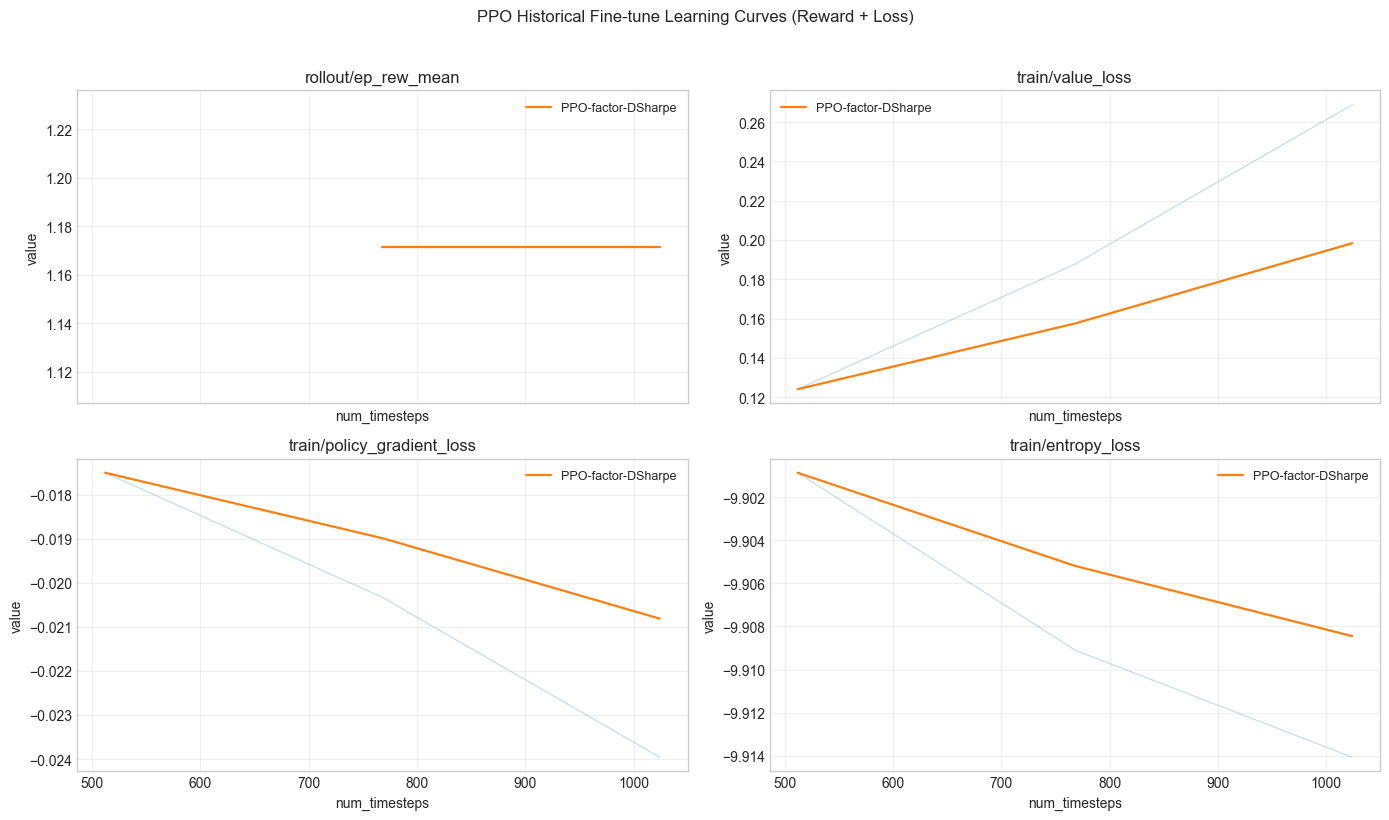

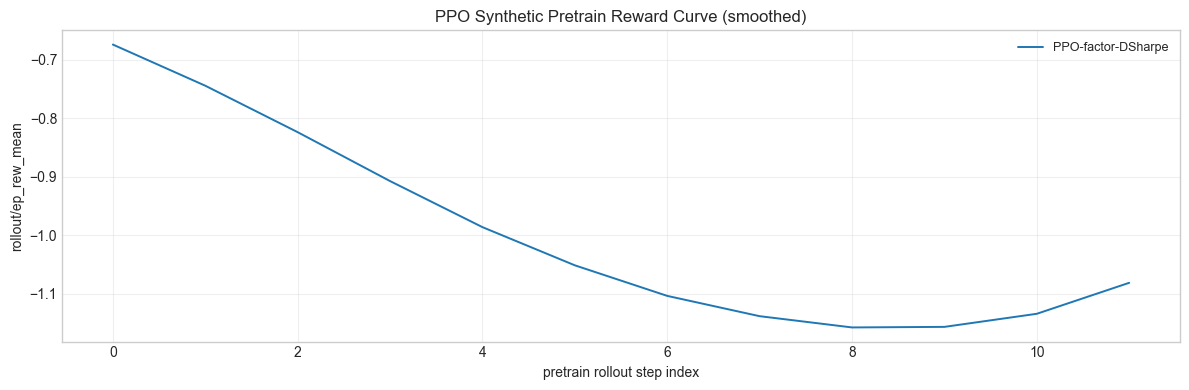

In [17]:

def plot_learning_curves(ppo_results, ppo_order, config):
    lc_cfg = config['rl'].get('learning_curve', {})
    if not bool(lc_cfg.get('enable', True)):
        print('Learning curve plotting is disabled by CONFIG.')
        return

    metrics = list(lc_cfg.get('metrics', [
        'rollout/ep_rew_mean',
        'train/value_loss',
        'train/policy_gradient_loss',
        'train/entropy_loss',
    ]))
    if len(metrics) == 0:
        print('No learning-curve metrics configured.')
        return

    smooth_span = max(1, int(lc_cfg.get('smooth_span', 20)))
    metric_plot_list = metrics[:4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax_i, ax in enumerate(axes):
        if ax_i >= len(metric_plot_list):
            ax.axis('off')
            continue

        metric = metric_plot_list[ax_i]
        has_any_series = False

        for key in ppo_order:
            info = ppo_results[key]
            label = info['label']
            train_log = info.get('historical_train_log', info.get('train_log', pd.DataFrame()))

            if len(train_log) == 0 or metric not in train_log.columns or 'num_timesteps' not in train_log.columns:
                continue

            x = pd.to_numeric(train_log['num_timesteps'], errors='coerce')
            y = pd.to_numeric(train_log[metric], errors='coerce')

            tmp = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
            if len(tmp) == 0:
                continue

            has_any_series = True
            ax.plot(tmp['x'], tmp['y'], linewidth=0.9, alpha=0.25)
            smooth_y = tmp['y'].ewm(span=smooth_span, min_periods=1).mean()
            ax.plot(tmp['x'], smooth_y, linewidth=1.6, label=label)

        ax.set_title(metric)
        ax.set_xlabel('num_timesteps')
        ax.set_ylabel('value')
        ax.grid(True, alpha=0.3)
        if has_any_series:
            ax.legend(fontsize=9)
        else:
            ax.text(0.5, 0.5, 'metric unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=10)

    fig.suptitle('PPO Historical Fine-tune Learning Curves (Reward + Loss)', y=1.02)
    plt.tight_layout()
    plt.show()

    pretrain_rows = []
    for key in ppo_order:
        info = ppo_results[key]
        pre_df = info.get('pretrain_log', pd.DataFrame())
        if len(pre_df) == 0:
            continue
        if 'rollout/ep_rew_mean' not in pre_df.columns:
            continue

        tmp = pre_df.copy()
        tmp['label'] = info['label']
        pretrain_rows.append(tmp)

    if len(pretrain_rows) > 0:
        merged = pd.concat(pretrain_rows, axis=0, ignore_index=True)
        fig, ax = plt.subplots(figsize=(12, 4))

        for label, grp in merged.groupby('label'):
            y = pd.to_numeric(grp['rollout/ep_rew_mean'], errors='coerce')
            y = y.replace([np.inf, -np.inf], np.nan).dropna()
            if len(y) == 0:
                continue

            x = np.arange(len(y))
            y_smooth = y.ewm(span=smooth_span, min_periods=1).mean()
            ax.plot(x, y_smooth, linewidth=1.4, label=label)

        ax.set_title('PPO Synthetic Pretrain Reward Curve (smoothed)')
        ax.set_xlabel('pretrain rollout step index')
        ax.set_ylabel('rollout/ep_rew_mean')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()


plot_learning_curves(ppo_results=ppo_results, ppo_order=ppo_order, config=CONFIG)


Common test window: 2019-01-04 -> 2026-03-13 (376 periods)
Performance metrics on common test window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
PPO-factor-DSharpe,0.2116,0.1931,1.0931,-0.2913,0.0456,0.5931
EQW,0.1500,0.1812,0.8642,-0.3431,0.0000,0.5851


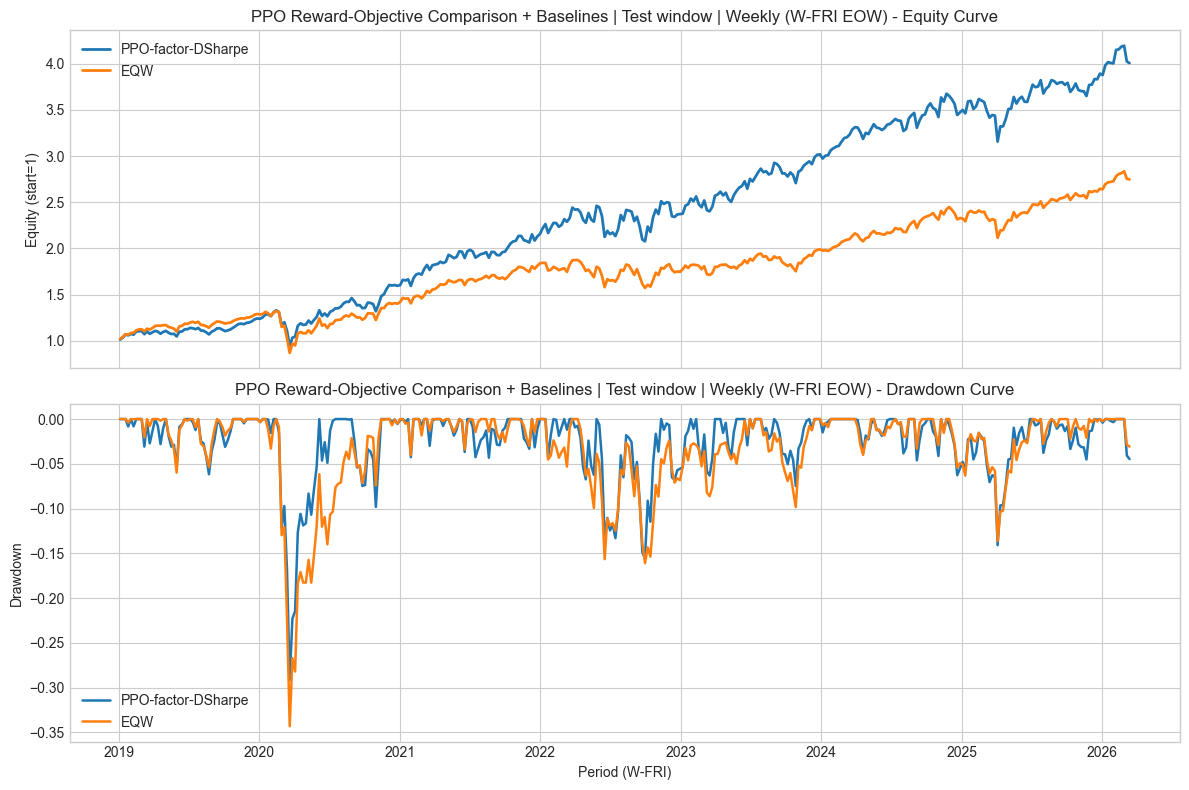

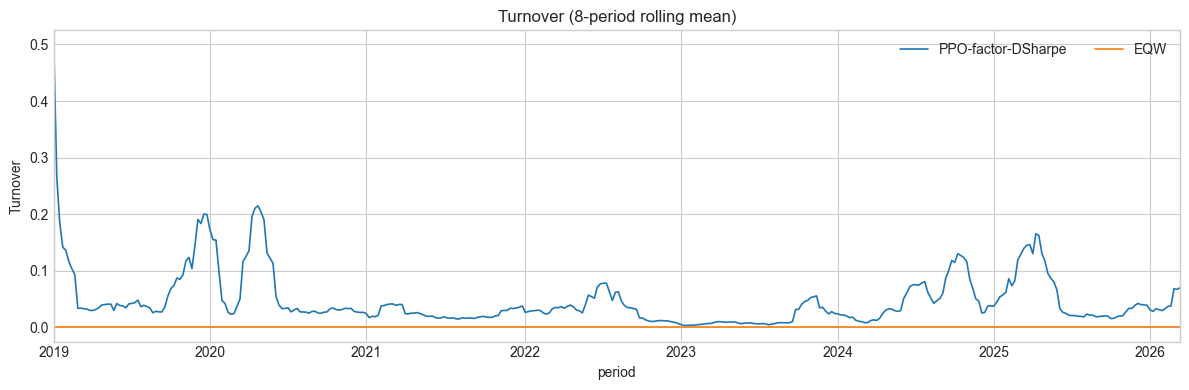

In [18]:
# ベースラインはテスト期間(適用リターン基準)で切り出し
split_date = pd.Timestamp(CONFIG['rl']['split_date'])

eqw_net_test = eqw_net.loc[eqw_net.index >= split_date]
eqw_turn_test = eqw_turnover.reindex(eqw_net_test.index)

ppo_series_map = {ppo_results[k]['label']: ppo_results[k]['net'] for k in ppo_order}
ppo_turn_map = {ppo_results[k]['label']: ppo_results[k]['turnover'] for k in ppo_order}

all_idx_list = list(ppo_series_map.values()) + [eqw_net_test]
common_idx = all_idx_list[0].index
for s in all_idx_list[1:]:
    common_idx = common_idx.intersection(s.index)

if len(common_idx) == 0:
    raise ValueError('No common test window among PPO variants and baselines.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common test window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

series_map = {k: v.reindex(common_idx) for k, v in ppo_series_map.items()}
series_map.update({
    'EQW': eqw_net_test.reindex(common_idx),
})

turn_map = {k: v.reindex(common_idx) for k, v in ppo_turn_map.items()}
turn_map.update({
    'EQW': eqw_turn_test.reindex(common_idx),
})

equity_map = {k: (1.0 + v).cumprod() for k, v in series_map.items()}
dd_map = {k: calc_drawdown(v) for k, v in equity_map.items()}

metrics_all = pd.DataFrame({
    k: calc_metrics(series_map[k], turn_map[k], RUNTIME['periods_per_year'])
    for k in series_map
}).T

print('Performance metrics on common test window:')
display(metrics_all)

assert np.isfinite(metrics_all[['CAGR', 'Vol', 'Sharpe', 'MDD', 'Turnover', 'Hit']].values).all(), 'Metrics contain NaN/inf.'

plot_equity_dd(
    equity_map=equity_map,
    dd_map=dd_map,
    title_prefix=f"PPO Reward-Objective Comparison + Baselines | Test window | {RUNTIME['frequency_label']}"
)

fig, ax = plt.subplots(figsize=(12, 4))
for k, v in turn_map.items():
    v.rolling(8, min_periods=1).mean().plot(ax=ax, label=k, linewidth=1.2)
ax.set_title('Turnover (8-period rolling mean)')
ax.set_ylabel('Turnover')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## 17) PPO診断（リーク・制約・コスト整合・行動統計）

Learning-log checks passed.
Macro load check passed.
Observation dimension check passed.
History reset/step check passed.
Reward formula/stability checks passed.
Weight constraints check passed (all PPO variants).
Cost consistency passed: PPO-factor-DSharpe max_diff=1.388e-17
Train/Test split consistency passed.
Macro timing check passed.
Leak check passed for PPO variants + baselines (including history lag checks).


,strategy,decision_period,max_signal_data_period,applied_return_period
0,PPO-factor-DSharpe,2018-12-28,2018-12-21,2019-01-04
1,PPO-factor-DSharpe,2019-01-04,2018-12-28,2019-01-11
2,PPO-factor-DSharpe,2019-01-11,2019-01-04,2019-01-18
3,PPO-factor-DSharpe,2019-01-18,2019-01-11,2019-01-25
4,PPO-factor-DSharpe,2019-01-25,2019-01-18,2019-02-01
5,PPO-factor-DSharpe,2019-02-01,2019-01-25,2019-02-08
6,PPO-factor-DSharpe,2019-02-08,2019-02-01,2019-02-15
7,PPO-factor-DSharpe,2019-02-15,2019-02-08,2019-02-22
8,PPO-factor-DSharpe,2019-02-22,2019-02-15,2019-03-01
9,PPO-factor-DSharpe,2019-03-01,2019-02-22,2019-03-08


PPO action/reward diagnostics:


,mode,reward_objective,action_l2_mean,action_l2_std,reward_raw_mean,reward_norm_mean,reward_mean,avg_turnover,net_periods
label,,,,,,,,,
PPO-factor-DSharpe,factor,differential_sharpe,1.1226,0.3622,0.3235,"3,619.5895",-0.0071,0.0456,376


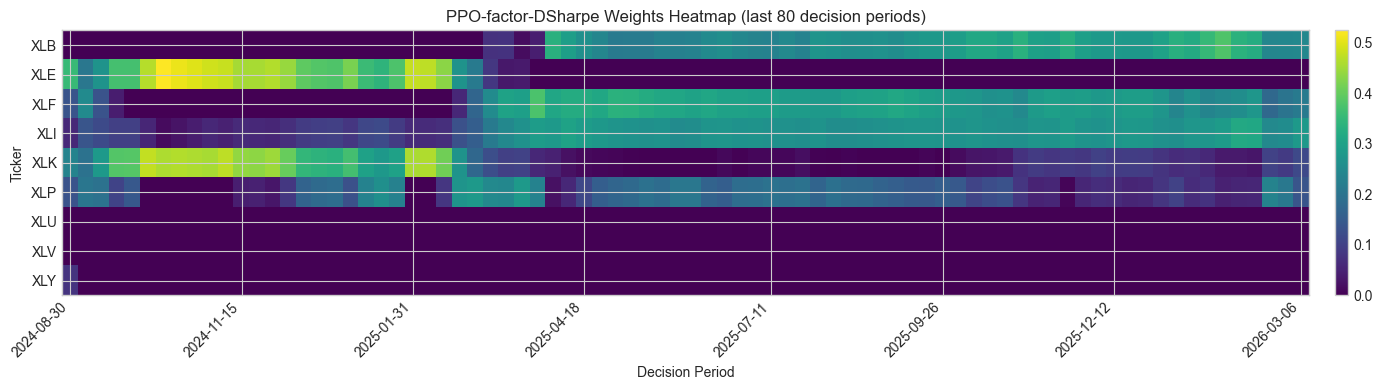

In [19]:
def assert_long_only_weights(weights_df, name='strategy', tol=1e-8):
    if weights_df.empty:
        raise AssertionError(f'{name}: empty weights')

    min_w = float(weights_df.min().min())
    if min_w < -tol:
        raise AssertionError(f'{name}: negative weight detected (min={min_w})')

    sums = weights_df.sum(axis=1)
    valid = ((np.abs(sums - 1.0) <= 1e-6) | (np.abs(sums) <= 1e-6))
    if not bool(valid.all()):
        bad = sums.loc[~valid].head(3)
        raise AssertionError(f'{name}: weight sum must be 1 or 0. bad sample={bad.to_dict()}')


def check_env_vs_backtest(step_df, net_series, name='strategy', tol=1e-10):
    if len(step_df) == 0:
        raise AssertionError(f'{name}: empty step_df')

    env_net = step_df.groupby('applied_period')['net'].sum().sort_index().rename('env_net')
    bt_net = net_series.sort_index().rename('bt_net')
    chk = pd.concat([env_net, bt_net], axis=1).dropna()
    if len(chk) == 0:
        raise AssertionError(f'{name}: no overlapping periods for env-vs-bt check')

    diff = (chk['env_net'] - chk['bt_net']).abs()
    max_diff = float(diff.max())
    assert max_diff <= tol, f'{name}: env vs backtest mismatch (max_diff={max_diff})'
    return max_diff



# -1) 学習ログ健全性検証
lc_cfg = CONFIG['rl'].get('learning_curve', {})
min_points_warn = int(lc_cfg.get('min_points_warn', 10))
smooth_span = max(1, int(lc_cfg.get('smooth_span', 20)))
required_curve_metrics = ['rollout/ep_rew_mean', 'train/value_loss']

for key in ppo_order:
    info = ppo_results[key]
    label = info['label']
    train_log = info.get('train_log', pd.DataFrame())

    assert len(train_log) > 0, f'{label}: empty train_log'
    assert 'num_timesteps' in train_log.columns, f'{label}: missing num_timesteps in train_log'

    ts = pd.to_numeric(train_log['num_timesteps'], errors='coerce')
    assert ts.notna().all(), f'{label}: num_timesteps has NaN'
    assert bool(pd.Series(ts).is_monotonic_increasing), f'{label}: num_timesteps must be monotonic increasing'

    if len(train_log) < min_points_warn:
        print(f'Warning: {label} train_log points={len(train_log)} < min_points_warn={min_points_warn}')

    for metric in required_curve_metrics:
        assert metric in train_log.columns, f'{label}: missing learning metric {metric}'
        y = pd.to_numeric(train_log[metric], errors='coerce')
        finite = np.isfinite(y.values)
        assert bool(finite.any()), f'{label}: no finite values in {metric}'

        y_clean = pd.Series(y).replace([np.inf, -np.inf], np.nan).dropna()
        if len(y_clean) > 0:
            y_smooth = y_clean.ewm(span=smooth_span, min_periods=1).mean()
            assert np.isfinite(y_smooth.values).all(), f'{label}: non-finite smoothed values in {metric}'

print('Learning-log checks passed.')

# 0) Macroロード検証
macro_cfg = CONFIG['rl']['macro']
if bool(macro_cfg.get('enable_macro', False)):
    assert len(macro_features) > 0, 'Macro feature is enabled but macro_features is empty.'
    assert macro_features.index.is_monotonic_increasing, 'macro_features index must be monotonic increasing.'
    assert all(pd.api.types.is_numeric_dtype(macro_features[c]) for c in macro_features.columns), 'All macro features must be numeric.'
    print('Macro load check passed.')

# 1) 観測次元検証
for key in ppo_order:
    info = ppo_results[key]
    env = info['test_env_obj']
    expected_dim = env.obs_feature_dim
    if env.include_action_history:
        expected_dim += env.history_len * len(env.tickers)
    expected_dim += env.history_len * len(env.agent_state_fields)
    assert env.obs_dim == expected_dim, f"{info['label']}: obs_dim mismatch env={env.obs_dim}, expected={expected_dim}"
    assert env.observation_space.shape[0] == expected_dim, f"{info['label']}: observation_space shape mismatch"

print('Observation dimension check passed.')

# 2) reset/step履歴更新検証
for key in ppo_order:
    info = ppo_results[key]
    env = info['test_env_obj']
    obs0, _ = env.reset(seed=int(CONFIG['rl']['seed']))

    action_hist_len = env.history_len * len(env.tickers) if env.include_action_history else 0
    state_hist_len = env.history_len * len(env.agent_state_fields)

    if action_hist_len > 0:
        action_hist0 = obs0[env.obs_feature_dim : env.obs_feature_dim + action_hist_len]
        assert np.allclose(action_hist0, 0.0), f"{info['label']}: action history must be zero at reset."

    state_hist0 = obs0[-state_hist_len:]
    assert np.allclose(state_hist0, 0.0), f"{info['label']}: state history must be zero at reset."

    test_action = np.zeros(env.action_space.shape, dtype=np.float32)
    obs1, reward1, terminated1, truncated1, step_info = env.step(test_action)

    if not (terminated1 or truncated1):
        if action_hist_len > 0:
            action_hist1 = obs1[env.obs_feature_dim : env.obs_feature_dim + action_hist_len].reshape(env.history_len, len(env.tickers))
            expected_last_action = step_info['weights'].reindex(env.tickers).fillna(0.0).values.astype(np.float32)
            assert np.allclose(action_hist1[-1], expected_last_action), f"{info['label']}: latest action history mismatch."

        state_hist1 = obs1[-state_hist_len:].reshape(env.history_len, len(env.agent_state_fields))
        field_to_idx = {f: i for i, f in enumerate(env.agent_state_fields)}
        assert abs(float(state_hist1[-1, field_to_idx['net']]) - float(step_info['net'])) < 1e-8, f"{info['label']}: latest net history mismatch."
        assert abs(float(state_hist1[-1, field_to_idx['turnover']]) - float(step_info['turnover'])) < 1e-8, f"{info['label']}: latest turnover history mismatch."

print('History reset/step check passed.')

# 3) 報酬健全性検証
for key in ppo_order:
    info = ppo_results[key]
    steps = info['steps']
    assert len(steps) > 0, f"{info['label']}: empty steps"
    assert np.isfinite(steps[['reward', 'reward_raw', 'reward_norm', 'risk_var_prev', 'risk_sigma_prev']].values).all(), f"{info['label']}: non-finite reward/risk detected"
    assert (steps['risk_var_prev'] >= -1e-12).all(), f"{info['label']}: negative risk variance detected"

    if bool(CONFIG['rl']['reward_stabilizer'].get('tanh_clip', True)):
        assert (steps['reward'].abs() <= 1.000001).all(), f"{info['label']}: reward out of tanh range"

    expected_obj = info['reward_objective']
    assert set(steps['reward_objective'].dropna().unique()) == {expected_obj}, f"{info['label']}: objective tag mismatch"

print('Reward formula/stability checks passed.')

# 4) 重み制約
for key in ppo_order:
    info = ppo_results[key]
    assert_long_only_weights(info['weights'], name=info['label'])
print('Weight constraints check passed (all PPO variants).')

# 5) コスト整合（env計算とrun_backtest再計算）
for key in ppo_order:
    info = ppo_results[key]
    max_diff = check_env_vs_backtest(
        step_df=info['steps'],
        net_series=info['net'],
        name=info['label'],
    )
    print(f"Cost consistency passed: {info['label']} max_diff={max_diff:.3e}")

# 6) 分割整合
for key in ppo_order:
    info = ppo_results[key]
    st = info['split_tbl']
    train_applied = st.loc[st['applied_period'] < split_date, 'applied_period']
    test_applied = st.loc[st['applied_period'] >= split_date, 'applied_period']

    assert len(set(train_applied).intersection(set(test_applied))) == 0, f"{info['label']}: applied period overlap"
    assert (train_applied < split_date).all(), f"{info['label']}: train applied period violation"
    assert (test_applied >= split_date).all(), f"{info['label']}: test applied period violation"

print('Train/Test split consistency passed.')

# 7) マクロ時点整合（VIX特徴はtまでのみ）
# 7) マクロ時点整合（各マクロ特徴はtまでのみ）
macro_cols = list(macro_features.columns)
if len(macro_cols) > 0:
    sampled_idx = rl_features.index[::max(1, len(rl_features) // 20)]
    for t in sampled_idx:
        assert t in rl_features.index, f'rl_features missing decision date: {t}'
        for name, s in macro_raw_series.items():
            if len(s) == 0:
                continue
            first_available = s.index.min()
            if t < first_available:
                continue
            assert (s.index <= t).any(), f'No macro history available up to decision date {t} for {name}'

    print('Macro timing check passed.')

# 8) リーク検証（既存関数を再利用）
leak_rows = []
for key in ppo_order:
    info = ppo_results[key]
    tbl = make_leak_check_table(info['net'], ret_p.index, name=info['label'])
    leak_rows.append(tbl)

for name, s in {
    'EQW': eqw_net_test,
}.items():
    leak_rows.append(make_leak_check_table(s, ret_p.index, name=name))

leak_tbl_all = pd.concat(leak_rows, axis=0).reset_index(drop=True)
valid_leak = leak_tbl_all.dropna(subset=['max_signal_data_period', 'decision_period', 'applied_return_period'])

assert (valid_leak['max_signal_data_period'] <= valid_leak['decision_period']).all(), 'Leak check failed: future info in signal.'
assert (valid_leak['decision_period'] < valid_leak['applied_return_period']).all(), 'Leak check failed: not applied to t+1.'

for key in ppo_order:
    info = ppo_results[key]
    steps_mode = info['steps'].copy()
    hist_valid = steps_mode.dropna(subset=['history_latest_period'])
    assert (hist_valid['history_latest_period'] <= hist_valid['decision_period']).all(), f"{info['label']}: history leakage detected."

print('Leak check passed for PPO variants + baselines (including history lag checks).')
display(valid_leak.head(14))

# 9) 行動・報酬統計
action_stats = []
for key in ppo_order:
    info = ppo_results[key]
    steps = info['steps']
    avg_turn = float(info['turnover'].mean()) if len(info['turnover']) > 0 else np.nan

    action_stats.append({
        'label': info['label'],
        'mode': info['mode'],
        'reward_objective': info['reward_objective'],
        'action_l2_mean': float(steps['action_l2'].mean()) if len(steps) > 0 else np.nan,
        'action_l2_std': float(steps['action_l2'].std(ddof=0)) if len(steps) > 0 else np.nan,
        'reward_raw_mean': float(steps['reward_raw'].mean()) if len(steps) > 0 else np.nan,
        'reward_norm_mean': float(steps['reward_norm'].mean()) if len(steps) > 0 else np.nan,
        'reward_mean': float(steps['reward'].mean()) if len(steps) > 0 else np.nan,
        'avg_turnover': avg_turn,
        'net_periods': int(len(info['net'])),
    })

action_stats_df = pd.DataFrame(action_stats).set_index('label')
print('PPO action/reward diagnostics:')
display(action_stats_df)

# 10) 重みヒートマップ（4 PPO系列）
n = len(ppo_order)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

for i, key in enumerate(ppo_order):
    info = ppo_results[key]
    w = info['weights'].copy().tail(min(len(info['weights']), 80))

    if len(w) == 0:
        axes[i].text(0.5, 0.5, 'No weights', ha='center', va='center')
        axes[i].set_axis_off()
        continue

    mat = w.T.values
    im = axes[i].imshow(mat, aspect='auto', cmap='viridis', interpolation='nearest')

    axes[i].set_title(f"{info['label']} Weights Heatmap (last {len(w)} decision periods)")
    axes[i].set_ylabel('Ticker')
    axes[i].set_yticks(np.arange(len(w.columns)))
    axes[i].set_yticklabels(w.columns)

    xticks = np.linspace(0, len(w.index) - 1, num=min(8, len(w.index)), dtype=int)
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels([w.index[j].date().isoformat() for j in xticks], rotation=45, ha='right')
    axes[i].set_xlabel('Decision Period')

    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()
